# M14 · Encoders & Contrastive Training — Hands-on, Step by Tiny Step

**Companion to lesson M14. Written for someone new to ML.**

Where do the embeddings from M11–M13 come from? **Encoders** turn raw text into vectors, and
**contrastive training** teaches them **which pairs should be close and which should separate**.
This is the bridge from "understands language" to "retrieves the right item."

**What you'll build (every step has an analogy, a tiny numeric trace, logging, and a picture):**
- **Part A · Encoders & the loss:** what a **sentence encoder** actually does
  (text → tokens → **pool** → **normalize**), **dual (= two-tower) vs cross-encoder**, how a
  cross-encoder is **actually used** (retrieve → rerank), **InfoNCE + temperature**, and
  **in-batch negatives** as an explicit score **matrix**.
- **Part B · Hard negatives & fine-tuning:** **triplet loss**, why hard negatives raise the
  gradient, the **real hard-negative mining pipeline**, and an end-to-end **fine-tuning recipe**.

Libraries: **PyTorch + scikit-learn + matplotlib** — all preinstalled in Colab. Run each cell
with **Shift+Enter**.

## Step 1 · Setup + synthetic data

Queries and their matched items share a hidden **topic + individual taste**, so a positive pair
should score high. We reuse this data throughout.

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from sklearn.metrics import roc_auc_score
torch.manual_seed(0)
plt.rcParams.update({"axes.grid": True, "grid.alpha": .3, "figure.autolayout": True})
BLUE, GREEN, RED, PURPLE, GOLD, GRAY = "#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974", "#888"

rng = np.random.default_rng(0)
D_raw, T = 24, 100
tcent = rng.normal(0, 1, (T, D_raw)) * 2.0                    # many topic centers
def make(n, seed):
    r = np.random.default_rng(seed)
    tp = r.integers(0, T, n)
    taste = r.normal(0, 1, (n, D_raw)) * 0.7                  # individual taste, shared query<->item
    base = tcent[tp] + taste
    q = base + r.normal(0, 0.35, (n, D_raw)); i = base + r.normal(0, 0.35, (n, D_raw))
    return torch.tensor(q, dtype=torch.float32), torch.tensor(i, dtype=torch.float32), tp
Q, I, tpq = make(6000, 1)
Qte, Ite, tpt = make(1500, 2)

print("data ready:", len(Q), "train pairs,", len(Qte), "test pairs,", T, "topics")

data ready: 6000 train pairs, 1500 test pairs, 100 topics


---
# Part 0 · ✍️ Toy Examples — trace each mechanic by hand

Before the full notebook, here is **one tiny, hand-traceable toy example for every computational
mechanic** in this lesson — synthetic positive pairs, pooling, normalization, self-attention,
role prefixes, positive/negative pairs, dual vs cross scoring, retrieve→rerank, InfoNCE,
temperature, in-batch negatives, training pressure, collapse, hard-negative mining, fine-tuning,
and held-out metrics. Each toy uses only `numpy` + `matplotlib`, prints every intermediate value,
pins the result with an `assert`, and draws exactly one picture.

## ✍️ Toy 1 · synthetic positives share topic + taste

The setup cell makes each query and its positive item from the same hidden **topic center** plus
the same **taste** vector, then adds tiny noise. That is why the positive item is closer than a
different-topic item.

topic id per pair: [0, 0, 1, 1, 2, 2]
base = topic + taste:
 [[ 0.2  0.1]
 [-0.1  0.2]
 [ 4.1 -0.2]
 [ 3.8  0.1]
 [ 0.1  4.2]
 [-0.2  3.9]]
query vectors:
 [[ 0.3  0.1]
 [-0.1  0.1]
 [ 4.2 -0.1]
 [ 3.8  0.2]
 [ 0.   4.2]
 [-0.1  3.9]]
positive item vectors:
 [[ 0.2  0.2]
 [-0.2  0.2]
 [ 4.1 -0.3]
 [ 3.9  0.1]
 [ 0.1  4.3]
 [-0.3  3.9]]
positive squared distances: [0.02, 0.02, 0.05, 0.02, 0.02, 0.04]
different-topic squared distances: [14.6, 16.0, 36.17, 30.5, 16.04, 13.7]


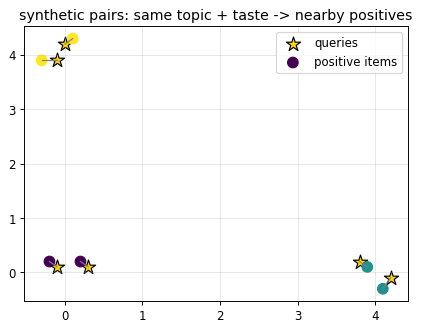

In [6]:
t1_topic = np.array([[0., 0.], [4., 0.], [0., 4.]])                         # -> 3 hidden topic centers
t1_tp = np.array([0, 0, 1, 1, 2, 2])                                         # -> 6 pairs, two per topic
t1_taste = np.array([[.2,.1],[-.1,.2],[.1,-.2],[-.2,.1],[.1,.2],[-.2,-.1]])  # -> one taste per pair
t1_base = t1_topic[t1_tp] + t1_taste                                         # -> shared clean pair location
t1_q_noise = np.array([[.1,0.],[0.,-.1],[.1,.1],[0.,.1],[-.1,0.],[.1,0.]])   # -> tiny query noise
t1_i_noise = np.array([[0.,.1],[-.1,0.],[0.,-.1],[.1,0.],[0.,.1],[-.1,0.]])  # -> tiny item noise
t1_Q = t1_base + t1_q_noise                                                  # -> noisy query vectors
t1_I = t1_base + t1_i_noise                                                  # -> noisy positive item vectors
t1_neg_idx = np.array([2, 3, 4, 5, 0, 1])                                    # -> different-topic negatives
t1_pos_d = ((t1_Q - t1_I)**2).sum(1)                                         # -> [0.02,0.02,0.05,0.02,0.02,0.04]
t1_neg_d = ((t1_Q - t1_I[t1_neg_idx])**2).sum(1)                             # -> much larger different-topic distances

print("topic id per pair:", t1_tp.tolist())
print("base = topic + taste:\n", np.round(t1_base, 2))
print("query vectors:\n", np.round(t1_Q, 2))
print("positive item vectors:\n", np.round(t1_I, 2))
print("positive squared distances:", np.round(t1_pos_d, 2).tolist())
print("different-topic squared distances:", np.round(t1_neg_d, 2).tolist())

assert np.all(t1_pos_d < t1_neg_d)

plt.figure(figsize=(5, 4))
plt.scatter(t1_Q[:,0], t1_Q[:,1], marker="*", s=160, c="gold", edgecolor="k", label="queries")
plt.scatter(t1_I[:,0], t1_I[:,1], s=80, c=t1_tp, cmap="viridis", label="positive items")
for t1_j in range(6):
    plt.plot([t1_Q[t1_j,0], t1_I[t1_j,0]], [t1_Q[t1_j,1], t1_I[t1_j,1]], color="gray", lw=1)
plt.title("synthetic pairs: same topic + taste -> nearby positives"); plt.legend(); plt.show()

▶ What you'll see: every query is connected to a nearby positive, while the different-topic distance is much larger. Step 1 scales this recipe to thousands of reusable pairs.

## ✍️ Toy 2 · mean-pool token vectors, then L2-normalize

A sentence encoder gets one vector per token, **averages** them into one sentence vector, then
L2-normalizes it so the length is exactly 1.

tokens: ['senior', 'data', 'role', 'remote']
token vectors:
 [[ 2.  0.]
 [ 0.  2.]
 [ 1.  1.]
 [ 1. -1.]]
mean pool: [1.0, 0.5]
pooled length: 1.118
normalized sentence vector: [0.894, 0.447]
normalized length: 1.0


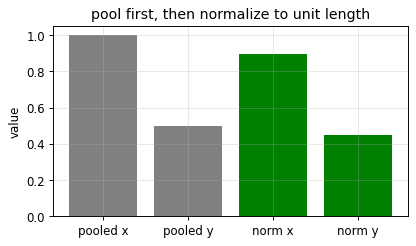

In [9]:
t2_tokens = ["senior", "data", "role", "remote"]                            # -> 4 tokens
t2_vecs = np.array([[2.,0.], [0.,2.], [1.,1.], [1.,-1.]])                   # -> 4 tiny token vectors
t2_pooled = t2_vecs.mean(0)                                                  # -> [1.0, 0.5]
t2_len = np.linalg.norm(t2_pooled)                                           # -> 1.1180339887
t2_sent = t2_pooled / t2_len                                                 # -> [0.894, 0.447]

print("tokens:", t2_tokens)
print("token vectors:\n", t2_vecs)
print("mean pool:", np.round(t2_pooled, 3).tolist())
print("pooled length:", round(float(t2_len), 3))
print("normalized sentence vector:", np.round(t2_sent, 3).tolist())
print("normalized length:", round(float(np.linalg.norm(t2_sent)), 3))

assert np.allclose(np.linalg.norm(t2_sent), 1.0)

plt.figure(figsize=(5, 3))
plt.bar(["pooled x","pooled y","norm x","norm y"], [t2_pooled[0], t2_pooled[1], t2_sent[0], t2_sent[1]], color=["gray","gray","green","green"])
plt.title("pool first, then normalize to unit length"); plt.ylabel("value"); plt.show()

▶ What you'll see: four token vectors average to `[1.0, 0.5]`, then normalization turns that into a unit-length sentence embedding `[0.894, 0.447]`.

## ✍️ Toy 3 · cosine ranking after normalization

Once vectors have length 1, the dot product is the **cosine similarity**. Retrieval ranks items by
that cosine score.

normalized query: [0.707, 0.707]
normalized docs:
 [[ 0.707  0.707]
 [ 1.     0.   ]
 [ 0.     1.   ]
 [ 0.707 -0.707]
 [-1.     0.   ]
 [-0.707 -0.707]]
cosine scores: [1.0, 0.707, 0.707, -0.0, -0.707, -1.0]
ranking best to worst: [0, 1, 2, 3, 4, 5]
top-3: [0, 1, 2]


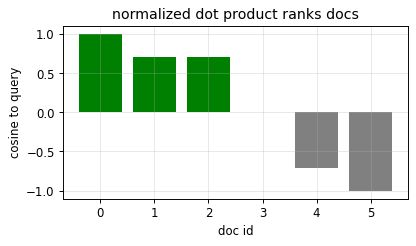

In [12]:
t3_q = np.array([1., 1.])                                                    # -> query direction
t3_docs = np.array([[1.,1.], [2.,0.], [0.,2.], [1.,-1.], [-1.,0.], [-1.,-1.]]) # -> 6 item vectors
t3_qn = t3_q / np.linalg.norm(t3_q)                                          # -> [0.707,0.707]
t3_dn = t3_docs / np.linalg.norm(t3_docs, axis=1, keepdims=True)             # -> unit item vectors
t3_scores = t3_dn @ t3_qn                                                    # -> [1.000,0.707,0.707,0.000,-0.707,-1.000]
t3_order = np.argsort(-t3_scores)                                            # -> [0,1,2,3,4,5]
t3_top3 = t3_order[:3].tolist()                                              # -> [0,1,2]

print("normalized query:", np.round(t3_qn, 3).tolist())
print("normalized docs:\n", np.round(t3_dn, 3))
print("cosine scores:", np.round(t3_scores, 3).tolist())
print("ranking best to worst:", t3_order.tolist())
print("top-3:", t3_top3)

assert t3_top3 == [0, 1, 2]

plt.figure(figsize=(5, 3))
plt.bar(range(6), t3_scores, color=["green" if t3_j in t3_top3 else "gray" for t3_j in range(6)])
plt.xlabel("doc id"); plt.ylabel("cosine to query"); plt.title("normalized dot product ranks docs"); plt.show()

▶ What you'll see: the doc pointing exactly with the query scores `1.0`, the half-aligned docs score `0.707`, and opposite docs fall below zero.

## ✍️ Toy 4 · self-attention = dot → softmax → weighted blend

Self-attention updates a token by measuring similarity to every token, softmaxing those scores,
then taking a weighted average of all token vectors.

tokens: ['remote', 'data', 'onsite', 'analyst']
token vectors:
 [[ 1.  0.]
 [ 0.  1.]
 [-1.  0.]
 [ 0.  1.]]
remote dot each token: [1.0, 0.0, -1.0, 0.0]
remote attention weights: [0.534, 0.197, 0.072, 0.197] sum = 1.0
new remote vector: [0.462, 0.393]
full updated token matrix:
 [[ 0.462  0.393]
 [ 0.     0.731]
 [-0.462  0.393]
 [ 0.     0.731]]


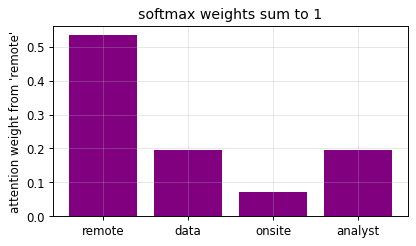

In [15]:
t4_names = ["remote", "data", "onsite", "analyst"]                           # -> 4 tokens
t4_M = np.array([[1.,0.], [0.,1.], [-1.,0.], [0.,1.]])                       # -> 2-D token vectors
t4_logits = t4_M[0] @ t4_M.T                                                  # -> [1,0,-1,0]
t4_exp = np.exp(t4_logits - t4_logits.max())                                  # -> [1.000,0.368,0.135,0.368]
t4_w = t4_exp / t4_exp.sum()                                                  # -> [0.534,0.197,0.072,0.197]
t4_new_remote = (t4_w[:, None] * t4_M).sum(0)                                 # -> [0.462,0.393]
t4_all_logits = t4_M @ t4_M.T                                                 # -> 4x4 token-token similarities
t4_all_w = np.exp(t4_all_logits - t4_all_logits.max(1, keepdims=True))        # -> unnormalized row weights
t4_all_w = t4_all_w / t4_all_w.sum(1, keepdims=True)                          # -> every row sums to 1
t4_all_new = t4_all_w @ t4_M                                                   # -> all 4 tokens updated

print("tokens:", t4_names)
print("token vectors:\n", t4_M)
print("remote dot each token:", t4_logits.tolist())
print("remote attention weights:", np.round(t4_w, 3).tolist(), "sum =", round(float(t4_w.sum()), 3))
print("new remote vector:", np.round(t4_new_remote, 3).tolist())
print("full updated token matrix:\n", np.round(t4_all_new, 3))

assert np.allclose(t4_w.sum(), 1.0) and np.allclose(t4_new_remote, [0.462117, 0.393224], atol=1e-5)

plt.figure(figsize=(5, 3))
plt.bar(t4_names, t4_w, color="purple")
plt.ylabel("attention weight from 'remote'"); plt.title("softmax weights sum to 1"); plt.show()

▶ What you'll see: `remote` pays most attention to itself, a little to the data-like tokens, and barely to the opposite `onsite`, producing a blended contextual vector.

## ✍️ Toy 5 · query/passage role prefix shifts the same words

E5-style prefixes add a small role signal before normalization. The **same words** can therefore
produce slightly different query-form and passage-form vectors.

same pooled words: [1.0, 1.0]
query raw: [1.5, 1.0] -> normalized [0.832, 0.555]
passage raw: [1.0, 1.5] -> normalized [0.555, 0.832]
cos(query-form, passage-form): 0.923


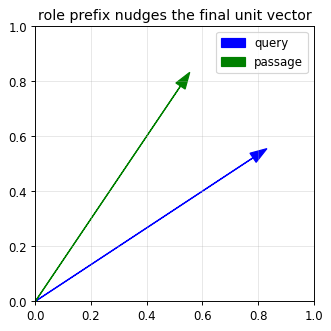

In [18]:
t5_base = np.array([1., 1.])                                                  # -> pooled words before role prefix
t5_q_shift = np.array([.5, 0.])                                                # -> query role bias
t5_p_shift = np.array([0., .5])                                                # -> passage role bias
t5_q_raw = t5_base + t5_q_shift                                                # -> [1.5,1.0]
t5_p_raw = t5_base + t5_p_shift                                                # -> [1.0,1.5]
t5_q_vec = t5_q_raw / np.linalg.norm(t5_q_raw)                                 # -> [0.832,0.555]
t5_p_vec = t5_p_raw / np.linalg.norm(t5_p_raw)                                 # -> [0.555,0.832]
t5_cos = t5_q_vec @ t5_p_vec                                                   # -> 0.923

print("same pooled words:", t5_base.tolist())
print("query raw:", t5_q_raw.tolist(), "-> normalized", np.round(t5_q_vec, 3).tolist())
print("passage raw:", t5_p_raw.tolist(), "-> normalized", np.round(t5_p_vec, 3).tolist())
print("cos(query-form, passage-form):", round(float(t5_cos), 3))

assert not np.allclose(t5_q_vec, t5_p_vec) and t5_cos > 0.9

plt.figure(figsize=(4, 4))
plt.arrow(0, 0, t5_q_vec[0], t5_q_vec[1], head_width=.04, color="blue", length_includes_head=True, label="query")
plt.arrow(0, 0, t5_p_vec[0], t5_p_vec[1], head_width=.04, color="green", length_includes_head=True, label="passage")
plt.xlim(0, 1); plt.ylim(0, 1); plt.legend(); plt.title("role prefix nudges the final unit vector"); plt.show()

▶ What you'll see: query and passage vectors remain close, but they are not identical — the role prefix nudges the direction before normalization.

## ✍️ Toy 6 · build positive and hard-negative pairs

For pair training, each query gets one labeled positive and one **same-topic different item** as a
hard negative. The labels become `1` for positives and `0` for negatives.

topics: [0, 0, 1, 1, 2, 2]
negative item picked for each query: [1, 0, 3, 2, 5, 4]
pair query ids: [0, 1, 2, 3, 4, 5, 0, 1, 2, 3, 4, 5]
pair item ids : [0, 1, 2, 3, 4, 5, 1, 0, 3, 2, 5, 4]
labels        : [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]
negative topics: [0, 0, 1, 1, 2, 2] (same as query topics)


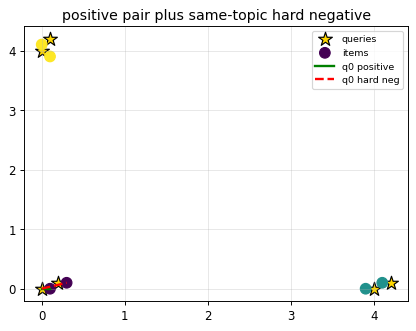

In [21]:
t6_topics = np.array([0, 0, 1, 1, 2, 2])                                      # -> item topic ids
t6_Q = np.array([[0.,0.], [.2,.1], [4.,0.], [4.2,.1], [0.,4.], [.1,4.2]])     # -> 6 query vectors
t6_I = np.array([[.1,0.], [.3,.1], [4.1,.1], [3.9,0.], [.1,3.9], [0.,4.1]])   # -> 6 positive items
t6_neg = np.array([1, 0, 3, 2, 5, 4])                                         # -> same-topic other item per query
t6_q_idx = np.concatenate([np.arange(6), np.arange(6)])                       # -> [0,1,2,3,4,5,0,1,2,3,4,5]
t6_i_idx = np.concatenate([np.arange(6), t6_neg])                             # -> positives then hard negatives
t6_y = np.concatenate([np.ones(6), np.zeros(6)])                              # -> [1,1,1,1,1,1,0,0,0,0,0,0]

print("topics:", t6_topics.tolist())
print("negative item picked for each query:", t6_neg.tolist())
print("pair query ids:", t6_q_idx.tolist())
print("pair item ids :", t6_i_idx.tolist())
print("labels        :", t6_y.astype(int).tolist())
print("negative topics:", t6_topics[t6_neg].tolist(), "(same as query topics)")

assert np.array_equal(t6_topics[t6_neg], t6_topics) and t6_y[:6].sum() == 6 and t6_y[6:].sum() == 0

plt.figure(figsize=(5, 4))
plt.scatter(t6_Q[:,0], t6_Q[:,1], marker="*", s=150, c="gold", edgecolor="k", label="queries")
plt.scatter(t6_I[:,0], t6_I[:,1], s=80, c=t6_topics, cmap="viridis", label="items")
plt.plot([t6_Q[0,0], t6_I[0,0]], [t6_Q[0,1], t6_I[0,1]], color="green", lw=2, label="q0 positive")
plt.plot([t6_Q[0,0], t6_I[t6_neg[0],0]], [t6_Q[0,1], t6_I[t6_neg[0],1]], color="red", lw=2, ls="--", label="q0 hard neg")
plt.title("positive pair plus same-topic hard negative"); plt.legend(fontsize=8); plt.show()

▶ What you'll see: the second half of the pair table swaps in same-topic but different items, creating hard negatives with label `0`.

## ✍️ Toy 7 · dual encoder score = precomputed item vector dot query vector

A dual encoder can precompute every item vector once. At query time, scoring is just a dot product
against those stored vectors.

query vector: [0.894, 0.447]
precomputed item vectors:
 [[ 1.     0.   ]
 [ 0.     1.   ]
 [ 0.707  0.707]
 [-1.     0.   ]
 [ 0.    -1.   ]
 [ 0.894  0.447]]
dual dot-product scores: [0.894, 0.447, 0.949, -0.894, -0.447, 1.0]
ranking: [5, 2, 0, 1, 4, 3]


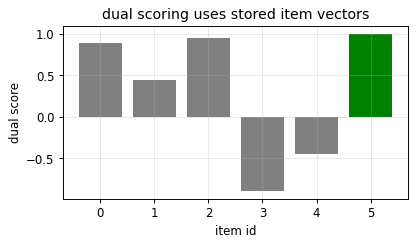

In [24]:
t7_q = np.array([1., .5])                                                     # -> one query embedding
t7_items = np.array([[1.,0.], [0.,1.], [1.,1.], [-1.,0.], [0.,-1.], [2.,1.]]) # -> 6 precomputed item embeddings
t7_qn = t7_q / np.linalg.norm(t7_q)                                           # -> [0.894,0.447]
t7_in = t7_items / np.linalg.norm(t7_items, axis=1, keepdims=True)            # -> normalized stored item vectors
t7_scores = t7_in @ t7_qn                                                     # -> [0.894,0.447,0.949,-0.894,-0.447,1.000]
t7_order = np.argsort(-t7_scores)                                             # -> [5,2,0,1,4,3]

print("query vector:", np.round(t7_qn, 3).tolist())
print("precomputed item vectors:\n", np.round(t7_in, 3))
print("dual dot-product scores:", np.round(t7_scores, 3).tolist())
print("ranking:", t7_order.tolist())

assert int(t7_order[0]) == 5 and np.isclose(t7_scores[5], 1.0)

plt.figure(figsize=(5, 3))
plt.bar(range(6), t7_scores, color=["green" if t7_j == t7_order[0] else "gray" for t7_j in range(6)])
plt.xlabel("item id"); plt.ylabel("dual score"); plt.title("dual scoring uses stored item vectors"); plt.show()

▶ What you'll see: item 5 has the same direction as the query, so the precomputed-vector dot product ranks it first without reading query and item jointly.

## ✍️ Toy 8 · cross score depends on the query–item pair

A cross-style scorer can use **interaction features** such as `query * item`. The same item can get
a different score for a different query, so there is no reusable standalone item score.

docs:
 [[ 1.  0.]
 [ 0.  1.]
 [ 1.  1.]
 [-1.  0.]
 [ 0. -1.]
 [ 2.  0.]]
query A interactions:
 [[ 1.  0.]
 [ 0.  0.]
 [ 1.  0.]
 [-1.  0.]
 [ 0. -0.]
 [ 2.  0.]]
query B interactions:
 [[ 0.  0.]
 [ 0.  1.]
 [ 0.  1.]
 [-0.  0.]
 [ 0. -1.]
 [ 0.  0.]]
cross scores for query A: [1.1, 0.1, 1.2, -1.1, -0.1, 2.2] top 5
cross scores for query B: [0.1, 1.1, 1.2, -0.1, -1.1, 0.2] top 2


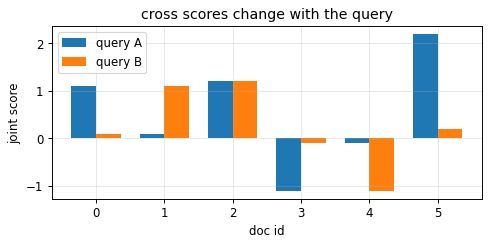

In [27]:
t8_docs = np.array([[1.,0.], [0.,1.], [1.,1.], [-1.,0.], [0.,-1.], [2.,0.]])  # -> 6 docs
t8_qA = np.array([1., 0.])                                                    # -> query A asks for x
t8_qB = np.array([0., 1.])                                                    # -> query B asks for y
t8_inter_A = t8_docs * t8_qA                                                  # -> pair interactions for query A
t8_inter_B = t8_docs * t8_qB                                                  # -> pair interactions for query B
t8_score_A = t8_inter_A.sum(1) + .1 * t8_docs.sum(1)                          # -> [1.1,0.1,1.2,-1.1,-0.1,2.2]
t8_score_B = t8_inter_B.sum(1) + .1 * t8_docs.sum(1)                          # -> [0.1,1.1,1.2,-0.1,-1.1,0.2]
t8_top_A = int(np.argmax(t8_score_A))                                         # -> 5
t8_top_B = int(np.argmax(t8_score_B))                                         # -> 2

print("docs:\n", t8_docs)
print("query A interactions:\n", t8_inter_A)
print("query B interactions:\n", t8_inter_B)
print("cross scores for query A:", np.round(t8_score_A, 2).tolist(), "top", t8_top_A)
print("cross scores for query B:", np.round(t8_score_B, 2).tolist(), "top", t8_top_B)

assert t8_top_A == 5 and t8_top_B == 2

plt.figure(figsize=(6, 3))
t8_x = np.arange(6)
plt.bar(t8_x - .18, t8_score_A, .36, label="query A")
plt.bar(t8_x + .18, t8_score_B, .36, label="query B")
plt.xlabel("doc id"); plt.ylabel("joint score"); plt.legend(); plt.title("cross scores change with the query"); plt.show()

▶ What you'll see: changing only the query changes the interaction columns and flips the top document, which is why cross-encoder scores cannot be precomputed per item.

## ✍️ Toy 9 · glued sequence → attention → [CLS] readout → head score

Inside a cross-encoder, query and doc tokens are glued into one sequence. Full self-attention lets
doc tokens flow into `[CLS]`, and a tiny head reads a single score from that `[CLS]` vector.

sequence: ['[CLS]', 'remote', 'data', '[SEP]', 'remote', 'data']
[CLS] logits: [0.5, 0.5, 0.5, 0.0, 0.5, 0.5]
[CLS] attention: [0.178, 0.178, 0.178, 0.108, 0.178, 0.178]
updated tokens:
 [[0.446 0.446]
 [0.621 0.28 ]
 [0.28  0.621]
 [0.417 0.417]
 [0.621 0.28 ]
 [0.28  0.621]]
[CLS] readout: [0.446, 0.446] score: 0.446 

sequence: ['[CLS]', 'remote', 'data', '[SEP]', 'onsite', 'data']
[CLS] logits: [0.5, 0.5, 0.5, 0.0, -0.5, 0.5]
[CLS] attention: [0.201, 0.201, 0.201, 0.122, 0.074, 0.201]
updated tokens:
 [[ 0.228  0.503]
 [ 0.41   0.365]
 [ 0.082  0.621]
 [ 0.083  0.417]
 [-0.306  0.344]
 [ 0.082  0.621]]
[CLS] readout: [0.228, 0.503] score: 0.228 

score docA: 0.446 score docB: 0.228


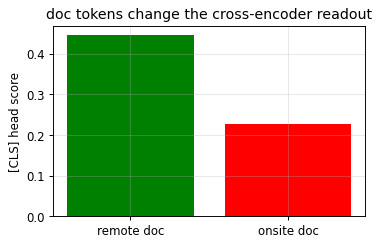

In [30]:
t9_tok = {"remote":np.array([1.,0.]), "data":np.array([0.,1.]), "onsite":np.array([-1.,0.]), "[SEP]":np.array([0.,0.])} # -> 2-D tokens
t9_q = ["remote", "data"]                                                     # -> query tokens
t9_docA = ["remote", "data"]                                                   # -> matching doc tokens
t9_docB = ["onsite", "data"]                                                   # -> opposing doc tokens
t9_head = np.array([1., 0.])                                                    # -> read remote-ness from [CLS]
def t9_score(t9_doc):
    t9_seq = ["[CLS]"] + t9_q + ["[SEP]"] + t9_doc                              # -> glued sequence length 6
    t9_cls0 = np.array([.5, .5])                                                # -> mean of query token directions
    t9_V = np.array([t9_cls0] + [t9_tok[t9_w] for t9_w in t9_seq[1:]])          # -> token matrix
    t9_logits = t9_V @ t9_V.T                                                   # -> full token-token dot matrix
    t9_E = np.exp(t9_logits - t9_logits.max(1, keepdims=True))                 # -> row-stable exponentials
    t9_A = t9_E / t9_E.sum(1, keepdims=True)                                    # -> attention rows sum to 1
    t9_new = t9_A @ t9_V                                                        # -> every token updated
    t9_readout = t9_new[0]                                                      # -> updated [CLS]
    t9_s = t9_head @ t9_readout                                                 # -> scalar score
    print("sequence:", t9_seq)
    print("[CLS] logits:", np.round(t9_logits[0], 3).tolist())
    print("[CLS] attention:", np.round(t9_A[0], 3).tolist())
    print("updated tokens:\n", np.round(t9_new, 3))
    print("[CLS] readout:", np.round(t9_readout, 3).tolist(), "score:", round(float(t9_s), 3), "\n")
    return float(t9_s)
t9_sA = t9_score(t9_docA)                                                       # -> matching doc score
t9_sB = t9_score(t9_docB)                                                       # -> opposing doc score

print("score docA:", round(t9_sA, 3), "score docB:", round(t9_sB, 3))

assert t9_sA > t9_sB

plt.figure(figsize=(4.5, 3))
plt.bar(["remote doc", "onsite doc"], [t9_sA, t9_sB], color=["green", "red"])
plt.ylabel("[CLS] head score"); plt.title("doc tokens change the cross-encoder readout"); plt.show()

▶ What you'll see: the matching doc pushes positive remote signal into `[CLS]`, while the `onsite` doc lowers it, so the head emits a smaller score.

## ✍️ Toy 10 · retrieve first, then rerank the short list

The dual encoder cheaply retrieves a top-K candidate set. The cross-encoder only re-scores that
short list, then re-sorts it.

dual scores over all 6: [0.92, 0.88, 0.7, 0.4, 0.1, 0.05]
dual topK item ids: [0, 1, 2] true rank: 2
cross scores on topK: {0: 0.6, 1: 0.95, 2: 0.55}
reranked item ids: [1, 0, 2] true rank: 1


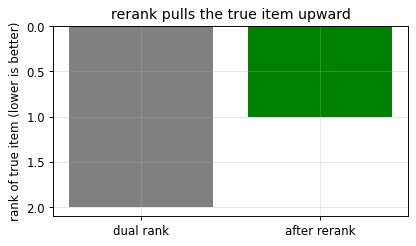

In [33]:
t10_true = 1                                                                  # -> true item id for this query
t10_dual_scores = np.array([.92, .88, .70, .40, .10, .05])                    # -> first-stage scores for 6 items
t10_topK = np.argsort(-t10_dual_scores)[:3]                                   # -> [0,1,2]
t10_dual_rank = int(np.where(t10_topK == t10_true)[0][0] + 1)                 # -> 2
t10_cross_scores = np.array([.60, .95, .55])                                  # -> cross scores for items [0,1,2]
t10_rerank_local = np.argsort(-t10_cross_scores)                              # -> [1,0,2] local positions
t10_reranked = t10_topK[t10_rerank_local]                                     # -> [1,0,2] item ids
t10_cross_rank = int(np.where(t10_reranked == t10_true)[0][0] + 1)            # -> 1

print("dual scores over all 6:", t10_dual_scores.tolist())
print("dual topK item ids:", t10_topK.tolist(), "true rank:", t10_dual_rank)
print("cross scores on topK:", dict(zip(t10_topK.tolist(), t10_cross_scores.tolist())))
print("reranked item ids:", t10_reranked.tolist(), "true rank:", t10_cross_rank)

assert t10_dual_rank == 2 and t10_cross_rank == 1 and t10_reranked[0] == t10_true

plt.figure(figsize=(5, 3))
plt.bar(["dual rank", "after rerank"], [t10_dual_rank, t10_cross_rank], color=["gray", "green"])
plt.gca().invert_yaxis(); plt.ylabel("rank of true item (lower is better)"); plt.title("rerank pulls the true item upward"); plt.show()

▶ What you'll see: the dual stage puts the true item second inside the top-3, then cross re-scoring moves it to rank 1.

## ✍️ Toy 11 · MRR and hit@1 from ranks

Retrieve→rerank is summarized with ranking metrics. **MRR** averages reciprocal rank; **hit@1**
counts how often the true item is first.

rankings:
 [[0 1 2 3 4 5]
 [0 1 2 3 4 5]
 [0 1 3 2 4 5]
 [3 0 1 2 4 5]
 [0 1 2 3 5 4]
 [0 1 5 2 3 4]]
true ids: [0, 1, 2, 3, 4, 5]
true-item ranks: [1, 2, 4, 1, 6, 3]
reciprocal ranks: [1.0, 0.5, 0.25, 1.0, 0.167, 0.333]
MRR: 0.542 hit@1: 0.333


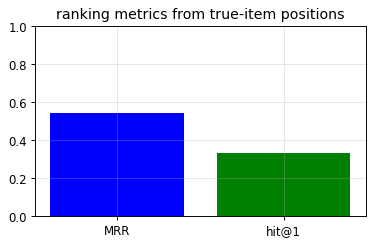

In [36]:
t11_orders = np.array([[0,1,2,3,4,5], [0,1,2,3,4,5], [0,1,3,2,4,5], [3,0,1,2,4,5], [0,1,2,3,5,4], [0,1,5,2,3,4]]) # -> 6 rankings
t11_true = np.array([0, 1, 2, 3, 4, 5])                                      # -> true item per query
t11_ranks = np.array([np.where(t11_orders[t11_i] == t11_true[t11_i])[0][0] + 1 for t11_i in range(6)]) # -> [1,2,4,1,6,3]
t11_rr = 1.0 / t11_ranks                                                      # -> [1,.5,.25,1,.167,.333]
t11_mrr = t11_rr.mean()                                                       # -> 0.542
t11_hit1 = np.mean(t11_ranks == 1)                                            # -> 0.333

print("rankings:\n", t11_orders)
print("true ids:", t11_true.tolist())
print("true-item ranks:", t11_ranks.tolist())
print("reciprocal ranks:", np.round(t11_rr, 3).tolist())
print("MRR:", round(float(t11_mrr), 3), "hit@1:", round(float(t11_hit1), 3))

assert np.all(t11_ranks == np.array([1,2,4,1,6,3])) and np.isclose(t11_hit1, 2/6)

plt.figure(figsize=(4.5, 3))
plt.bar(["MRR", "hit@1"], [t11_mrr, t11_hit1], color=["blue", "green"])
plt.ylim(0, 1); plt.title("ranking metrics from true-item positions"); plt.show()

▶ What you'll see: rank 1 contributes `1.0`, rank 2 contributes `0.5`, and rank 6 contributes only `0.167`; hit@1 is just the fraction of ranks equal to 1.

## ✍️ Toy 12 · InfoNCE softmax loss for one positive and negatives

InfoNCE turns scores into a softmax probability for the positive, then uses `-log(probability)` as
the loss.

scores: [2.0, 1.0, 0.0, -1.0]
shifted scores: [0.0, -1.0, -2.0, -3.0]
exp: [1.0, 0.368, 0.135, 0.05]
softmax probabilities: [0.644, 0.237, 0.087, 0.032]
positive probability: 0.644
InfoNCE loss: 0.44


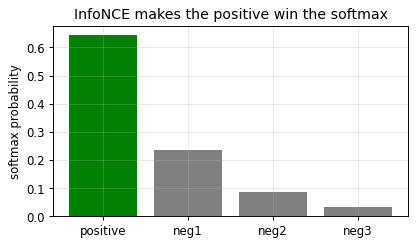

In [39]:
t12_scores = np.array([2., 1., 0., -1.])                                      # -> positive first, then 3 negatives
t12_z = t12_scores - t12_scores.max()                                         # -> [0,-1,-2,-3]
t12_exp = np.exp(t12_z)                                                       # -> [1.000,0.368,0.135,0.050]
t12_prob = t12_exp / t12_exp.sum()                                            # -> [0.644,0.237,0.087,0.032]
t12_loss = -np.log(t12_prob[0])                                               # -> 0.440

print("scores:", t12_scores.tolist())
print("shifted scores:", t12_z.tolist())
print("exp:", np.round(t12_exp, 3).tolist())
print("softmax probabilities:", np.round(t12_prob, 3).tolist())
print("positive probability:", round(float(t12_prob[0]), 3))
print("InfoNCE loss:", round(float(t12_loss), 3))

assert np.isclose(t12_prob[0], 0.643914, atol=1e-5) and np.isclose(t12_loss, 0.44019, atol=1e-5)

plt.figure(figsize=(5, 3))
plt.bar(["positive", "neg1", "neg2", "neg3"], t12_prob, color=["green", "gray", "gray", "gray"])
plt.ylabel("softmax probability"); plt.title("InfoNCE makes the positive win the softmax"); plt.show()

▶ What you'll see: the positive gets probability about `0.644`; the loss is `-log(0.644)`, so training tries to push that probability toward 1.

## ✍️ Toy 13 · temperature sharpens or softens the same scores

Temperature divides the scores before softmax. A lower `τ` makes the same score gap look bigger.

scores: [2.0, 1.0, 0.0, -1.0]
temperatures: [1.0, 0.5, 0.25]
positive probabilities: [0.644, 0.865, 0.982]


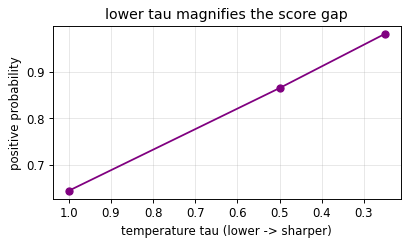

In [42]:
t13_scores = np.array([2., 1., 0., -1.])                                      # -> same scores as Toy 12
t13_tau = np.array([1.0, .5, .25])                                             # -> three temperatures
t13_probs = []
for t13_t in t13_tau:
    t13_z = t13_scores / t13_t                                                # -> scores scaled by tau
    t13_z = t13_z - t13_z.max()                                                # -> stable shifted scores
    t13_p = np.exp(t13_z) / np.exp(t13_z).sum()                                # -> row softmax
    t13_probs.append(t13_p[0])                                                 # -> positive probability
t13_probs = np.array(t13_probs)                                                # -> [0.644,0.865,0.982]

print("scores:", t13_scores.tolist())
print("temperatures:", t13_tau.tolist())
print("positive probabilities:", np.round(t13_probs, 3).tolist())

assert np.all(np.diff(t13_probs) > 0) and t13_probs[-1] > 0.98

plt.figure(figsize=(5, 3))
plt.plot(t13_tau, t13_probs, "o-", color="purple")
plt.gca().invert_xaxis(); plt.xlabel("temperature tau (lower -> sharper)"); plt.ylabel("positive probability")
plt.title("lower tau magnifies the score gap"); plt.show()

▶ What you'll see: with identical raw scores, lowering `τ` moves the positive probability from about `0.64` to about `0.98`.

## ✍️ Toy 14 · in-batch negatives are the off-diagonal of a score matrix

For `B` matched query–item pairs, the diagonal entries are positives. Every off-diagonal entry is
a free in-batch negative.

score matrix S = Q @ P.T:
 [[ 1.    0.1  -1.    0.1   0.78 -0.62]
 [ 0.1   1.    0.1  -1.    0.62  0.78]
 [-1.   -0.1   1.   -0.1  -0.78  0.62]
 [-0.1  -1.   -0.1   1.   -0.62 -0.78]
 [ 0.77  0.77 -0.63 -0.63  0.99  0.11]
 [-0.63  0.63  0.77 -0.77 -0.11  0.99]]
diagonal positives: [1.0, 1.0, 1.0, 1.0, 0.99, 0.99]
off-diagonal mean: -0.123
InfoNCE labels: [0, 1, 2, 3, 4, 5] (pick the diagonal column)


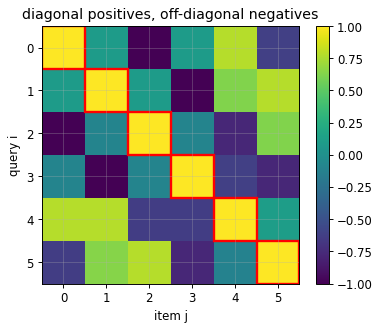

In [45]:
t14_Q = np.array([[1.,0.], [0.,1.], [-1.,0.], [0.,-1.], [1.,1.], [-1.,1.]])   # -> 6 query vectors
t14_P = np.array([[1.,.1], [.1,1.], [-1.,.1], [.1,-1.], [1.,.8], [-.8,1.]])   # -> 6 paired positive vectors
t14_Qn = t14_Q / np.linalg.norm(t14_Q, axis=1, keepdims=True)                # -> normalized queries
t14_Pn = t14_P / np.linalg.norm(t14_P, axis=1, keepdims=True)                # -> normalized positives
t14_S = t14_Qn @ t14_Pn.T                                                     # -> 6x6 cosine score matrix
t14_diag = np.diag(t14_S)                                                     # -> positive scores
t14_off = t14_S[~np.eye(6, dtype=bool)]                                       # -> 30 in-batch negatives

print("score matrix S = Q @ P.T:\n", np.round(t14_S, 2))
print("diagonal positives:", np.round(t14_diag, 2).tolist())
print("off-diagonal mean:", round(float(t14_off.mean()), 3))
print("InfoNCE labels:", list(range(6)), "(pick the diagonal column)")

assert t14_diag.mean() > t14_off.mean() and len(t14_off) == 30

plt.figure(figsize=(4.8, 4))
plt.imshow(t14_S, cmap="viridis", vmin=-1, vmax=1)
for t14_j in range(6):
    plt.gca().add_patch(plt.Rectangle((t14_j-.5, t14_j-.5), 1, 1, fill=False, edgecolor="red", lw=2))
plt.colorbar(fraction=0.046); plt.xlabel("item j"); plt.ylabel("query i"); plt.title("diagonal positives, off-diagonal negatives"); plt.show()

▶ What you'll see: the red diagonal is high because those are matched pairs; all other cells are negatives supplied for free by the batch.

## ✍️ Toy 15 · matrix rows become cross-entropy losses

InfoNCE on a batch is cross-entropy row by row: softmax each row, then take `-log` of the diagonal
probability.

score matrix:
 [[2. 0. 0.]
 [0. 2. 1.]
 [1. 0. 2.]]
row softmax:
 [[0.787 0.107 0.107]
 [0.09  0.665 0.245]
 [0.245 0.09  0.665]]
diagonal probabilities: [0.787, 0.665, 0.665]
per-query losses: [0.24, 0.408, 0.408]
batch InfoNCE loss: 0.352


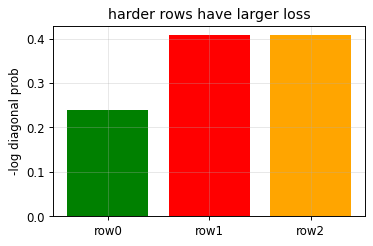

In [48]:
t15_S = np.array([[2., 0., 0.], [0., 2., 1.], [1., 0., 2.]])                 # -> 3 query x 3 item scores
t15_tau = 1.0                                                                 # -> no scaling for hand math
t15_Z = t15_S / t15_tau                                                       # -> same matrix
t15_Z = t15_Z - t15_Z.max(1, keepdims=True)                                  # -> stable row shift
t15_E = np.exp(t15_Z)                                                         # -> row exponentials
t15_P = t15_E / t15_E.sum(1, keepdims=True)                                  # -> row softmax probabilities
t15_losses = -np.log(np.diag(t15_P))                                          # -> per-query losses
t15_loss = t15_losses.mean()                                                  # -> batch mean loss

print("score matrix:\n", t15_S)
print("row softmax:\n", np.round(t15_P, 3))
print("diagonal probabilities:", np.round(np.diag(t15_P), 3).tolist())
print("per-query losses:", np.round(t15_losses, 3).tolist())
print("batch InfoNCE loss:", round(float(t15_loss), 3))

assert t15_losses[1] > t15_losses[0] and np.isclose(t15_loss, t15_losses.mean())

plt.figure(figsize=(4.5, 3))
plt.bar(["row0", "row1", "row2"], t15_losses, color=["green", "red", "orange"])
plt.ylabel("-log diagonal prob"); plt.title("harder rows have larger loss"); plt.show()

▶ What you'll see: row 1 has an extra high off-diagonal score, so its diagonal probability is lower and its loss is higher.

## ✍️ Toy 16 · one InfoNCE update pushes away a hard negative

For one query, the softmax gradient points toward the probability-weighted average item minus the
positive item. A small update increases the positive-vs-hard-negative gap.

old scores [positive, hard neg]: [1.0, 0.8]
softmax probabilities: [0.55, 0.45]
gradient wrt query: [-0.09, 0.27]
updated query: [0.992, -0.128]
new scores [positive, hard neg]: [0.992, 0.717]
score gap before: 0.2 after: 0.275


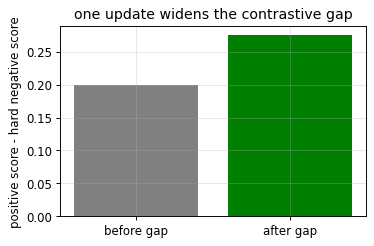

In [51]:
t16_q = np.array([1., 0.])                                                     # -> current query vector
t16_items = np.array([[1.,0.], [.8,.6]])                                      # -> positive then hard negative
t16_scores = t16_items @ t16_q                                                 # -> [1.0,0.8]
t16_p = np.exp(t16_scores - t16_scores.max())                                 # -> [1.000,0.819]
t16_p = t16_p / t16_p.sum()                                                    # -> [0.550,0.450]
t16_grad = t16_p @ t16_items - t16_items[0]                                   # -> [-0.090,0.270]
t16_lr = .5                                                                    # -> small learning rate
t16_q_new = t16_q - t16_lr * t16_grad                                         # -> [1.045,-0.135]
t16_q_new = t16_q_new / np.linalg.norm(t16_q_new)                             # -> [0.992,-0.128]
t16_new_scores = t16_items @ t16_q_new                                        # -> [0.992,0.717]
t16_gap_before = t16_scores[0] - t16_scores[1]                                # -> 0.200
t16_gap_after = t16_new_scores[0] - t16_new_scores[1]                         # -> 0.275

print("old scores [positive, hard neg]:", np.round(t16_scores, 3).tolist())
print("softmax probabilities:", np.round(t16_p, 3).tolist())
print("gradient wrt query:", np.round(t16_grad, 3).tolist())
print("updated query:", np.round(t16_q_new, 3).tolist())
print("new scores [positive, hard neg]:", np.round(t16_new_scores, 3).tolist())
print("score gap before:", round(float(t16_gap_before), 3), "after:", round(float(t16_gap_after), 3))

assert t16_gap_after > t16_gap_before

plt.figure(figsize=(4.5, 3))
plt.bar(["before gap", "after gap"], [t16_gap_before, t16_gap_after], color=["gray", "green"])
plt.ylabel("positive score - hard negative score"); plt.title("one update widens the contrastive gap"); plt.show()

▶ What you'll see: the hard negative gets enough probability to create a gradient, and one small update widens the positive-minus-negative score gap.

## ✍️ Toy 17 · alignment and uniformity catch representation collapse

Contrastive learning needs **alignment** (matched pairs close) and **uniformity** (all embeddings
spread out). A collapsed space can align positives but has terrible uniformity.

good alignment distance: 0.022
collapsed alignment distance: 0.000102
good off-diagonal cosine mean: -0.091
collapsed off-diagonal cosine mean: 1.0


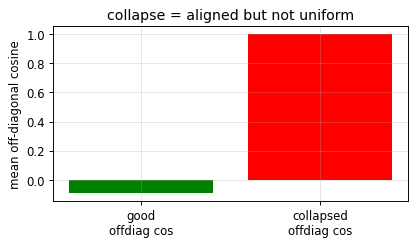

In [54]:
t17_angles = np.linspace(0, 2*np.pi, 6, endpoint=False)                       # -> 6 directions around a circle
t17_Q_good = np.c_[np.cos(t17_angles), np.sin(t17_angles)]                    # -> spread query embeddings
t17_P_good = np.c_[np.cos(t17_angles + .15), np.sin(t17_angles + .15)]        # -> nearby positives
t17_Q_bad = np.tile(np.array([[1., 0.]]), (6, 1))                             # -> collapsed queries
t17_P_bad = np.tile(np.array([[.99, .01]]), (6, 1))                           # -> collapsed positives
t17_P_bad = t17_P_bad / np.linalg.norm(t17_P_bad, axis=1, keepdims=True)      # -> unit collapsed positives
t17_align_good = ((t17_Q_good - t17_P_good)**2).sum(1).mean()                 # -> small positive-pair distance
t17_align_bad = ((t17_Q_bad - t17_P_bad)**2).sum(1).mean()                    # -> tiny positive-pair distance
t17_all_good = np.vstack([t17_Q_good, t17_P_good])                            # -> 12 spread embeddings
t17_all_bad = np.vstack([t17_Q_bad, t17_P_bad])                               # -> 12 collapsed embeddings
t17_off_good = (t17_all_good @ t17_all_good.T)[~np.eye(12, dtype=bool)].mean() # -> low average off-diagonal cosine
t17_off_bad = (t17_all_bad @ t17_all_bad.T)[~np.eye(12, dtype=bool)].mean()    # -> near 1.0 collapsed cosine

print("good alignment distance:", round(float(t17_align_good), 3))
print("collapsed alignment distance:", round(float(t17_align_bad), 6))
print("good off-diagonal cosine mean:", round(float(t17_off_good), 3))
print("collapsed off-diagonal cosine mean:", round(float(t17_off_bad), 3))

assert t17_align_bad < t17_align_good and t17_off_bad > 0.99 and t17_off_good < 0.1

plt.figure(figsize=(5, 3))
plt.bar(["good\noffdiag cos", "collapsed\noffdiag cos"], [t17_off_good, t17_off_bad], color=["green", "red"])
plt.ylabel("mean off-diagonal cosine"); plt.title("collapse = aligned but not uniform"); plt.show()

▶ What you'll see: collapsed positives are close, but every vector also points the same way; uniformity exposes the failure.

## ✍️ Toy 18 · triplet margin loss

Triplet loss is zero only when the positive score beats the negative score by at least the margin.
Hard negatives close to the positive keep the loss positive.

positive score: 3.0
negative scores: [0.2, 2.8, 3.2]
margin + neg - pos: [-2.3, 0.3, 0.7]
triplet losses: [0.0, 0.3, 0.7]


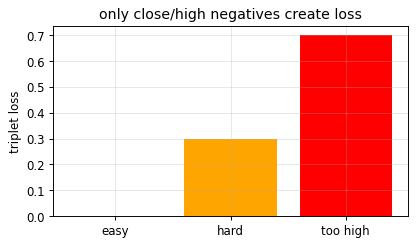

In [57]:
t18_pos = 3.0                                                                  # -> positive score
t18_negs = np.array([0.2, 2.8, 3.2])                                          # -> easy, hard, worse-than-positive negatives
t18_margin = .5                                                                # -> required safety gap
t18_raw = t18_margin + t18_negs - t18_pos                                     # -> [-2.3,0.3,0.7]
t18_loss = np.maximum(0.0, t18_raw)                                           # -> [0.0,0.3,0.7]

print("positive score:", t18_pos)
print("negative scores:", t18_negs.tolist())
print("margin + neg - pos:", np.round(t18_raw, 2).tolist())
print("triplet losses:", np.round(t18_loss, 2).tolist())

assert np.allclose(t18_loss, [0.0, 0.3, 0.7])

plt.figure(figsize=(5, 3))
plt.bar(["easy", "hard", "too high"], t18_loss, color=["gray", "orange", "red"])
plt.ylabel("triplet loss"); plt.title("only close/high negatives create loss"); plt.show()

▶ What you'll see: the easy negative has zero loss, while the hard negative still violates the margin and therefore creates training pressure.

## ✍️ Toy 19 · a hard negative steals softmax probability

In a softmax, a high-scoring negative puts a large term in the denominator. That lowers the
positive probability and raises the loss.

scores WITH hard: [3.0, 0.2, 2.8]
probabilities WITH hard: [0.532, 0.032, 0.436] loss 0.631
scores WITHOUT hard: [3.0, 0.2]
probabilities WITHOUT hard: [0.943, 0.057] loss 0.059


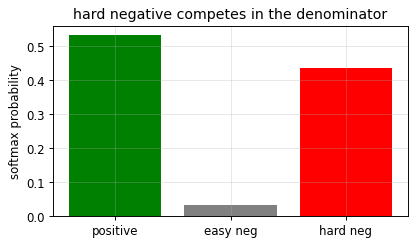

In [60]:
t19_with_scores = np.array([3.0, 0.2, 2.8])                                  # -> positive, easy neg, hard neg
t19_without_scores = np.array([3.0, 0.2])                                     # -> positive, easy neg only
t19_with_exp = np.exp(t19_with_scores - t19_with_scores.max())                # -> exponentials with hard neg
t19_without_exp = np.exp(t19_without_scores - t19_without_scores.max())       # -> exponentials without hard neg
t19_with_p = t19_with_exp / t19_with_exp.sum()                                # -> [0.532,0.032,0.436]
t19_without_p = t19_without_exp / t19_without_exp.sum()                       # -> [0.943,0.057]
t19_with_loss = -np.log(t19_with_p[0])                                        # -> 0.632
t19_without_loss = -np.log(t19_without_p[0])                                  # -> 0.059

print("scores WITH hard:", t19_with_scores.tolist())
print("probabilities WITH hard:", np.round(t19_with_p, 3).tolist(), "loss", round(float(t19_with_loss), 3))
print("scores WITHOUT hard:", t19_without_scores.tolist())
print("probabilities WITHOUT hard:", np.round(t19_without_p, 3).tolist(), "loss", round(float(t19_without_loss), 3))

assert t19_with_p[0] < t19_without_p[0] and t19_with_loss > t19_without_loss

plt.figure(figsize=(5, 3))
plt.bar(["positive", "easy neg", "hard neg"], t19_with_p, color=["green", "gray", "red"])
plt.ylabel("softmax probability"); plt.title("hard negative competes in the denominator"); plt.show()

▶ What you'll see: adding the hard negative drops the positive probability from about `0.94` to about `0.53`, keeping the loss and gradient high.

## ✍️ Toy 20 · mine hard negatives by retrieving top non-positives

Mining starts with the current model: score the corpus, rank it, remove the labeled positive, and
keep high-ranked non-positives as candidate hard negatives.

scores: [1.0, 0.995, 0.8, 0.0, -1.0, -0.196]
ranked ids: [0, 1, 2, 3, 5, 4]
labeled positive: 0
top non-positives kept as candidate hard negatives: [1, 2, 3]


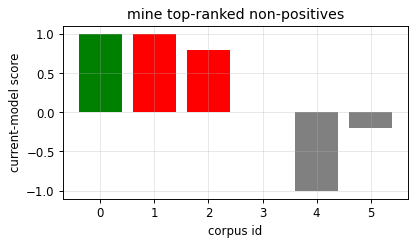

In [63]:
t20_q = np.array([1., 0.])                                                     # -> one query embedding
t20_corp = np.array([[1.,0.], [.95,.1], [.8,.6], [0.,1.], [-1.,0.], [-.2,-1.]]) # -> 6 corpus embeddings
t20_corp = t20_corp / np.linalg.norm(t20_corp, axis=1, keepdims=True)          # -> normalized corpus
t20_pos_id = 0                                                                 # -> labeled positive id
t20_scores = t20_corp @ t20_q                                                  # -> cosine retrieval scores
t20_ranked = np.argsort(-t20_scores)                                           # -> [0,1,2,3,5,4]
t20_candidates = [int(t20_r) for t20_r in t20_ranked[:4] if t20_r != t20_pos_id] # -> [1,2,3]

print("scores:", np.round(t20_scores, 3).tolist())
print("ranked ids:", t20_ranked.tolist())
print("labeled positive:", t20_pos_id)
print("top non-positives kept as candidate hard negatives:", t20_candidates)

assert t20_candidates == [1, 2, 3]

plt.figure(figsize=(5, 3))
plt.bar(range(6), t20_scores, color=["green" if t20_j == t20_pos_id else ("red" if t20_j in t20_candidates else "gray") for t20_j in range(6)])
plt.xlabel("corpus id"); plt.ylabel("current-model score"); plt.title("mine top-ranked non-positives"); plt.show()

▶ What you'll see: ids 1, 2, and 3 are not labeled positive but rank near the top, so they are candidate hard negatives.

## ✍️ Toy 21 · filter likely false negatives with a margin

Some mined candidates score almost the same as the positive; they may be unlabeled true matches.
The margin rule drops candidates within `margin` of the positive score.

positive score: 1.0 margin: 0.05 threshold: 0.95
candidate ids: [1, 2, 3, 4, 5]
candidate scores: [0.99, 0.86, 0.6, 0.2, -0.1]
dropped as false-negative risk: [1]
kept hard negatives: [2, 3, 4, 5]


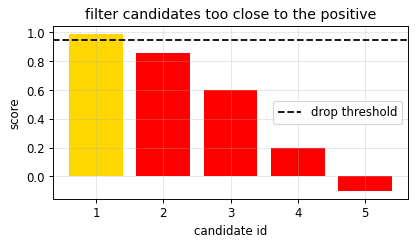

In [66]:
t21_ids = np.array([1, 2, 3, 4, 5])                                           # -> mined non-positive ids
t21_scores = np.array([.99, .86, .60, .20, -.10])                             # -> candidate scores
t21_pos_score = 1.00                                                           # -> labeled positive score
t21_margin = .05                                                               # -> false-negative safety margin
t21_threshold = t21_pos_score - t21_margin                                    # -> 0.95
t21_drop_mask = t21_scores >= t21_threshold                                   # -> [True,False,False,False,False]
t21_dropped = t21_ids[t21_drop_mask].tolist()                                 # -> [1]
t21_kept = t21_ids[~t21_drop_mask].tolist()                                   # -> [2,3,4,5]

print("positive score:", t21_pos_score, "margin:", t21_margin, "threshold:", t21_threshold)
print("candidate ids:", t21_ids.tolist())
print("candidate scores:", t21_scores.tolist())
print("dropped as false-negative risk:", t21_dropped)
print("kept hard negatives:", t21_kept)

assert t21_dropped == [1] and t21_kept == [2, 3, 4, 5]

plt.figure(figsize=(5, 3))
plt.bar(t21_ids, t21_scores, color=["gold" if t21_j in t21_dropped else "red" for t21_j in t21_ids])
plt.axhline(t21_threshold, color="black", ls="--", label="drop threshold")
plt.xlabel("candidate id"); plt.ylabel("score"); plt.legend(); plt.title("filter candidates too close to the positive"); plt.show()

▶ What you'll see: candidate 1 is so close to the positive that it is dropped, while lower scoring candidates are kept as safer hard negatives.

## ✍️ Toy 22 · hard-negative training improves fine-grained recall

Easy negatives separate broad topics, but hard negatives sharpen within-topic distinctions. Compare
two tiny score matrices with recall@1 and recall@3.

  hit flags @ 1: [True, False, False, True, False, True]
  hit flags @ 1: [True, True, True, True, True, True]
  hit flags @ 3: [True, True, True, True, True, True]
  hit flags @ 3: [True, True, True, True, True, True]
easy-neg score matrix:
 [[0.8  0.7  0.1  0.   0.   0.  ]
 [0.75 0.7  0.1  0.   0.   0.  ]
 [0.   0.   0.6  0.65 0.2  0.  ]
 [0.   0.   0.62 0.7  0.1  0.  ]
 [0.   0.   0.   0.   0.55 0.6 ]
 [0.   0.   0.   0.   0.58 0.62]]
hard-neg score matrix:
 [[0.9  0.5  0.1  0.   0.   0.  ]
 [0.45 0.88 0.1  0.   0.   0.  ]
 [0.   0.   0.87 0.5  0.2  0.  ]
 [0.   0.   0.4  0.86 0.1  0.  ]
 [0.   0.   0.   0.   0.84 0.4 ]
 [0.   0.   0.   0.   0.35 0.83]]
recall@1 easy vs hard: 0.5 1.0
recall@3 easy vs hard: 1.0 1.0


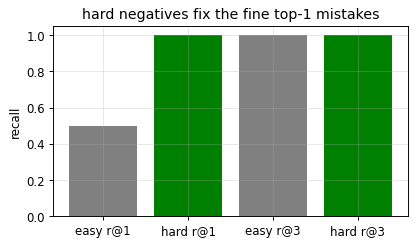

In [69]:
t22_easy = np.array([[.80,.70,.10,0,0,0], [.75,.70,.10,0,0,0], [0,0,.60,.65,.20,0], [0,0,.62,.70,.10,0], [0,0,0,0,.55,.60], [0,0,0,0,.58,.62]]) # -> some within-topic swaps
t22_hard = np.array([[.90,.50,.10,0,0,0], [.45,.88,.10,0,0,0], [0,0,.87,.50,.20,0], [0,0,.40,.86,.10,0], [0,0,0,0,.84,.40], [0,0,0,0,.35,.83]]) # -> diagonals sharpened
def t22_recall_at(t22_S, t22_k):
    t22_hits = [t22_i in np.argsort(-t22_S[t22_i])[:t22_k] for t22_i in range(6)] # -> one hit flag per query
    print(f"  hit flags @ {t22_k}:", t22_hits)
    return float(np.mean(t22_hits))
t22_easy_r1 = t22_recall_at(t22_easy, 1)                                      # -> 0.500
t22_hard_r1 = t22_recall_at(t22_hard, 1)                                      # -> 1.000
t22_easy_r3 = t22_recall_at(t22_easy, 3)                                      # -> 1.000
t22_hard_r3 = t22_recall_at(t22_hard, 3)                                      # -> 1.000

print("easy-neg score matrix:\n", t22_easy)
print("hard-neg score matrix:\n", t22_hard)
print("recall@1 easy vs hard:", t22_easy_r1, t22_hard_r1)
print("recall@3 easy vs hard:", t22_easy_r3, t22_hard_r3)

assert t22_easy_r1 == 0.5 and t22_hard_r1 == 1.0 and t22_easy_r3 == 1.0

plt.figure(figsize=(5, 3))
plt.bar(["easy r@1", "hard r@1", "easy r@3", "hard r@3"], [t22_easy_r1, t22_hard_r1, t22_easy_r3, t22_hard_r3], color=["gray","green","gray","green"])
plt.ylim(0, 1.05); plt.ylabel("recall"); plt.title("hard negatives fix the fine top-1 mistakes"); plt.show()

▶ What you'll see: recall@3 was already perfect, but hard-negative training fixes the close within-topic swaps and lifts recall@1 from `0.5` to `1.0`.

## ✍️ Toy 23 · fine-tuning rounds reshape the vectors

Fine-tuning starts from a pretrained space, then repeated hard-negative rounds move positives
closer to the query and hard negatives farther away.

positive vectors by round:
 [[0.8   0.6  ]
 [0.908 0.419]
 [0.958 0.285]]
hard-negative vectors by round:
 [[0.9   0.436]
 [0.676 0.737]
 [0.232 0.973]]
positive scores: [0.8, 0.908, 0.958]
hard-negative scores: [0.9, 0.676, 0.232]
score gaps: [-0.1, 0.232, 0.726]


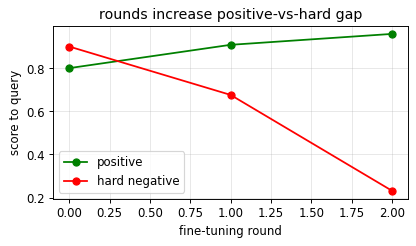

In [72]:
t23_q = np.array([1., 0.])                                                     # -> fixed query direction for the trace
t23_p0 = np.array([.8, .6])                                                     # -> positive initially okay
t23_h0 = np.array([.9, .436])                                                   # -> hard negative initially scores higher
t23_p0 = t23_p0 / np.linalg.norm(t23_p0)                                       # -> [0.800,0.600]
t23_h0 = t23_h0 / np.linalg.norm(t23_h0)                                       # -> [0.900,0.436]
t23_p1 = t23_p0 + .5 * t23_q                                                   # -> pull positive toward query
t23_h1 = t23_h0 - .5 * t23_q                                                   # -> push hard negative away from query
t23_p1 = t23_p1 / np.linalg.norm(t23_p1)                                      # -> [0.908,0.419]
t23_h1 = t23_h1 / np.linalg.norm(t23_h1)                                      # -> [0.676,0.737]
t23_p2 = t23_p1 + .5 * t23_q                                                   # -> second positive pull
t23_h2 = t23_h1 - .5 * t23_q                                                   # -> second hard-negative push
t23_p2 = t23_p2 / np.linalg.norm(t23_p2)                                      # -> [0.958,0.285]
t23_h2 = t23_h2 / np.linalg.norm(t23_h2)                                      # -> [0.232,0.973]
t23_pos_scores = np.array([t23_q @ t23_p0, t23_q @ t23_p1, t23_q @ t23_p2])   # -> [0.800,0.908,0.958]
t23_hard_scores = np.array([t23_q @ t23_h0, t23_q @ t23_h1, t23_q @ t23_h2])  # -> [0.900,0.676,0.232]

print("positive vectors by round:\n", np.round(np.vstack([t23_p0, t23_p1, t23_p2]), 3))
print("hard-negative vectors by round:\n", np.round(np.vstack([t23_h0, t23_h1, t23_h2]), 3))
print("positive scores:", np.round(t23_pos_scores, 3).tolist())
print("hard-negative scores:", np.round(t23_hard_scores, 3).tolist())
print("score gaps:", np.round(t23_pos_scores - t23_hard_scores, 3).tolist())

assert t23_pos_scores[-1] > t23_pos_scores[0] and t23_hard_scores[-1] < t23_hard_scores[0]

plt.figure(figsize=(5, 3))
plt.plot([0,1,2], t23_pos_scores, "o-", color="green", label="positive")
plt.plot([0,1,2], t23_hard_scores, "o-", color="red", label="hard negative")
plt.xlabel("fine-tuning round"); plt.ylabel("score to query"); plt.legend(); plt.title("rounds increase positive-vs-hard gap"); plt.show()

▶ What you'll see: the positive score rises while the hard-negative score falls across rounds, mimicking the geometry change in the fine-tuning loop.

## ✍️ Toy 24 · nDCG rewards relevant items near the top

Recall asks whether relevant items appeared; **nDCG** also rewards putting high-relevance items
early by discounting lower ranks with `1/log2(rank+1)`.

ranking: ['d1', 'd2', 'd3', 'd4', 'd5', 'd6']
relevance: [0, 2, 0, 1, 0, 1]
discounts: [1.0, 0.631, 0.5, 0.431, 0.387, 0.356]
discounted gains: [0.0, 1.262, 0.0, 0.431, 0.0, 0.356]
DCG: 2.049
ideal relevance: [2, 1, 1, 0, 0, 0] IDCG: 3.131
nDCG: 0.654


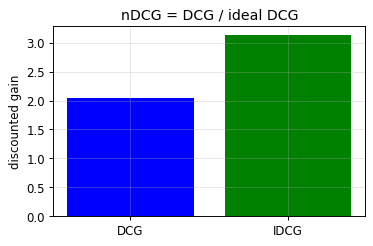

In [75]:
t24_ranked = ["d1", "d2", "d3", "d4", "d5", "d6"]                            # -> model ranking
t24_rel = np.array([0., 2., 0., 1., 0., 1.])                                  # -> graded relevance in that order
t24_discount = 1 / np.log2(np.arange(2, 8))                                   # -> [1.000,0.631,0.500,0.431,0.387,0.356]
t24_gain = t24_rel * t24_discount                                             # -> discounted gains
t24_dcg = t24_gain.sum()                                                       # -> 2.049
t24_ideal_rel = np.sort(t24_rel)[::-1]                                        # -> [2,1,1,0,0,0]
t24_idcg = (t24_ideal_rel * t24_discount).sum()                               # -> 3.131
t24_ndcg = t24_dcg / t24_idcg                                                  # -> 0.654

print("ranking:", t24_ranked)
print("relevance:", t24_rel.astype(int).tolist())
print("discounts:", np.round(t24_discount, 3).tolist())
print("discounted gains:", np.round(t24_gain, 3).tolist())
print("DCG:", round(float(t24_dcg), 3))
print("ideal relevance:", t24_ideal_rel.astype(int).tolist(), "IDCG:", round(float(t24_idcg), 3))
print("nDCG:", round(float(t24_ndcg), 3))

assert np.isclose(t24_ndcg, 0.654, atol=0.001)

plt.figure(figsize=(4.5, 3))
plt.bar(["DCG", "IDCG"], [t24_dcg, t24_idcg], color=["blue", "green"])
plt.ylabel("discounted gain"); plt.title("nDCG = DCG / ideal DCG"); plt.show()

▶ What you'll see: the best item is at rank 2, so DCG is below the ideal ordering; nDCG is the normalized ratio, about `0.654`.

---
# Part A · Encoders & the contrastive objective

## Step 2 · What a "sentence encoder" actually does

An **encoder** turns text into **one vector**. But a transformer outputs **one vector per
token**, not one per sentence. The step that collapses many token vectors into a single
sentence vector is **pooling**. The full pipeline is four moves:

```
text     "senior data scientist role"
  |  (1) TOKENIZE          -> split into (sub)word tokens
tokens   [senior, data, scientist, role]
  |  (2) TRANSFORMER       -> each token becomes a contextual vector
vectors  [.9,.1,0,.1] [.2,.9,.1,0] [.3,.8,.2,.1] [.2,.6,.3,.1]
  |  (3) POOL (mean)       -> average the token vectors into ONE
pooled   [.54, .81, .20, .10]
  |  (4) L2-NORMALIZE      -> length 1, so dot product == cosine
vector   the sentence embedding  (this is what M11 stores, M13 indexes)
```

We fake the transformer with a tiny hand-made vocab so you can watch every number. Real
encoders learn these token vectors — the **pool + normalize** recipe is identical.

encode the QUERY:
  tokens: ['senior', 'data', 'scientist', 'role']
    senior    -> [0.9 0.1 0.  0.1]
    data      -> [0.2 0.9 0.1 0. ]
    scientist -> [0.3 0.8 0.2 0.1]
    role      -> [0.2 0.6 0.3 0.1]
  mean pool     -> [0.4   0.6   0.15  0.075]
  normalized    -> [0.54  0.81  0.203 0.101]  (length 1.0 )

cos(query, A='hiring senior data scientist') = 0.970   <- shares 'senior data scientist'
cos(query, B='junior engineer remote role')  = 0.835   <- fewer shared tokens


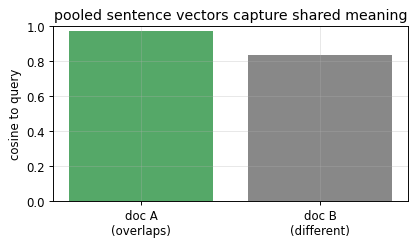

In [79]:
# a tiny toy "transformer output": each known word -> a 4-dim vector
vocab = {
 "senior":[0.9,0.1,0.0,0.1], "data":[0.2,0.9,0.1,0.0], "scientist":[0.3,0.8,0.2,0.1],
 "hiring":[0.1,0.2,0.9,0.1], "remote":[0.0,0.1,0.2,0.9], "role":[0.2,0.6,0.3,0.1],
 "junior":[0.6,0.1,0.0,0.5], "engineer":[0.4,0.7,0.2,0.1],
}
vocab = {k: np.array(v) for k, v in vocab.items()}

def sentence_encode(text, log=False):
    toks = [t for t in text.lower().split() if t in vocab]         # (1) tokenize
    vecs = np.array([vocab[t] for t in toks])                      # (2) per-token vectors
    pooled = vecs.mean(0)                                          # (3) MEAN POOL
    vec = pooled / np.linalg.norm(pooled)                          # (4) L2 normalize
    if log:
        print("  tokens:", toks)
        for t in toks: print(f"    {t:10}-> {vocab[t]}")
        print("  mean pool     ->", pooled.round(3))
        print("  normalized    ->", vec.round(3), " (length", round(np.linalg.norm(vec),3), ")")
    return vec

print("encode the QUERY:"); q = sentence_encode("senior data scientist role", log=True)

A = sentence_encode("hiring senior data scientist")
B = sentence_encode("junior engineer remote role")

print(f"\ncos(query, A='hiring senior data scientist') = {q@A:.3f}   <- shares 'senior data scientist'")
print(f"cos(query, B='junior engineer remote role')  = {q@B:.3f}   <- fewer shared tokens")

plt.figure(figsize=(5,3)); plt.bar(["doc A\n(overlaps)","doc B\n(different)"], [q@A, q@B], color=[GREEN, GRAY])
plt.ylabel("cosine to query"); plt.ylim(0,1); plt.title("pooled sentence vectors capture shared meaning"); plt.show()

### The transformer step, unpacked — **self-attention**

Step (2) above just said "each token becomes a contextual vector" — here is *how*, because the
cross-encoder in Step 4 reuses the exact same mechanism. That step is **self-attention**.
Definition first, then numbers:

> **Self-attention** gives each token a **new vector** that is a **weighted average of all the
> tokens in the sentence**, where each weight says *how much this token should pay attention to
> that one*. For one token: **(a)** measure its similarity (dot product) to every token;
> **(b)** softmax those into weights that sum to 1 (those weights are the "attention");
> **(c)** new vector = Σ weight · token. **"self"** = the tokens attend to **each other** (same
> sentence); **"full"** = **every** token does this, so they **all** update.

We watch one token attend, then all of them. (Real transformers first multiply each token by
learned **Query/Key/Value** matrices; here those are the identity, so the weight is just the
plain dot product — same idea.)

In [81]:
def selfattn_softmax(z): z = np.array(z, float); z = z - z.max(); e = np.exp(z); return e / e.sum()

# 2-D tokens so every number is visible (dim0 = "remote-ness", dim1 = "data-ness")
Stoks = {"remote": np.array([1.,0.]), "data": np.array([0.,1.]), "onsite": np.array([-1.,0.])}
names = list(Stoks); M = np.array([Stoks[n] for n in names])

print("tokens:", {n: Stoks[n].tolist() for n in names}, "\n")

print("ONE token, 'remote', attends to ALL tokens:")

sims = [M[0] @ M[j] for j in range(len(names))]             # (a) similarity to every token

print("  (a) dot(remote, each) =", np.round(sims, 2), "for tokens", names)

w = selfattn_softmax(sims)                                  # (b) softmax -> attention weights

print("  (b) softmax -> weights =", w.round(3), " (sum = 1)")

new_remote = (w[:, None] * M).sum(0)                        # (c) weighted blend of all tokens

print("  (c) new 'remote' = sum(weight * token) =", new_remote.round(3), " (was [1, 0])")

print("\nFULL self-attention = repeat for EVERY token, so they ALL update:")

for i, n in enumerate(names):
    wi = selfattn_softmax([M[i] @ M[j] for j in range(len(names))])
    print(f"   {n:7} weights {wi.round(2)} -> new {(wi[:, None] * M).sum(0).round(3)}")

print("\nA transformer stacks many such layers; THEN pool + normalize (above) -> sentence vector.")

tokens: {'remote': [1.0, 0.0], 'data': [0.0, 1.0], 'onsite': [-1.0, 0.0]} 

ONE token, 'remote', attends to ALL tokens:
  (a) dot(remote, each) = [ 1.  0. -1.] for tokens ['remote', 'data', 'onsite']
  (b) softmax -> weights = [0.665 0.245 0.09 ]  (sum = 1)
  (c) new 'remote' = sum(weight * token) = [0.575 0.245]  (was [1, 0])

FULL self-attention = repeat for EVERY token, so they ALL update:
   remote  weights [0.67 0.24 0.09] -> new [0.575 0.245]
   data    weights [0.21 0.58 0.21] -> new [0.    0.576]
   onsite  weights [0.09 0.24 0.67] -> new [-0.575  0.245]

A transformer stacks many such layers; THEN pool + normalize (above) -> sentence vector.


### E5 and IRPS — real sentence encoders

The toy above is exactly how real ones work, with two additions:

- **E5** (a popular open encoder) is a transformer trained **contrastively** on query–passage
  pairs, then **mean-pooled + normalized**. Its trick: prepend a **role prefix** —
  `"query: ..."` for the search text and `"passage: ..."` for documents — because retrieval is
  **asymmetric** (a short question vs a long answer) and the prefix tells the model which side
  it is encoding.
- **IRPS** is LinkedIn's in-house retrieval/sentence encoder: same **transformer → pool →
  normalize** recipe, trained contrastively but tuned on LinkedIn data and tasks.

We simulate the E5 prefix effect: the **same words** get a slightly different vector depending
on whether they are encoded as a query or a passage.

In [83]:
# simulate role prefixes: a tiny additive "query:" vs "passage:" bias vector
qpref = np.array([0.10, 0.00, -0.05, 0.00])
ppref = np.array([-0.05, 0.05, 0.10, 0.00])
def encode_with_role(text, role):
    base = np.array([vocab[t] for t in text.lower().split() if t in vocab]).mean(0)
    base = base + (qpref if role == "query" else ppref)          # role prefix shifts the vector
    return base / np.linalg.norm(base)
same = "senior data scientist"
as_q = encode_with_role(same, "query"); as_p = encode_with_role(same, "passage")

print(f"'{same}' as QUERY   -> {as_q.round(3)}")
print(f"'{same}' as PASSAGE -> {as_p.round(3)}")
print(f"cosine(query-form, passage-form) = {as_q@as_p:.3f}  (close, but NOT identical)")
print("-> the same text encodes differently by role; that's what the E5 prefix buys you.")

'senior data scientist' as QUERY   -> [0.683 0.723 0.06  0.08 ]
'senior data scientist' as PASSAGE -> [0.521 0.812 0.25  0.083]
cosine(query-form, passage-form) = 0.965  (close, but NOT identical)
-> the same text encodes differently by role; that's what the E5 prefix buys you.


## Step 3 · Dual (two-tower) encoder vs cross-encoder

Two shapes for scoring a (query, item) pair:

- **Dual encoder** — embeds query and item **separately**; score = dot product. **This is the
  same thing as the "two-tower" (or "bi-encoder", or "Siamese") model from M12** — two names for
  one architecture. Because the item vector depends on the **item alone**, it can be
  **precomputed & indexed** → perfect for **first-stage retrieval** (M12/M13).
- **Cross-encoder** — reads the **pair together** (query and item tokens attend across each
  other), so it can compare exact phrases. **More accurate**, but the score depends on **both**
  inputs at once, so there is **no standalone item vector to store** → must run **once per pair**.

We train both on match/no-match pairs and compare **pair accuracy (AUC)** on **hard**
(same-topic) pairs.

pair-match AUC on HARD (same-topic) pairs:  dual (two-tower) 0.626   cross-encoder 0.721
dual: embed once, index, ANN-search millions.  cross: O(pairs) -> rerank hundreds only.


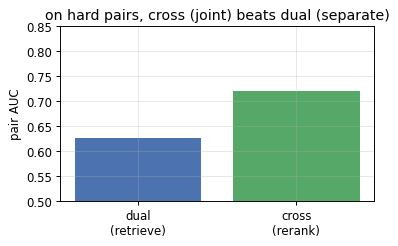

In [85]:
def pairs(Qs, Is, tp, seed):
    r = np.random.default_rng(seed); n = len(Qs); neg = np.zeros(n, dtype=int)
    for j in range(n):                                    # HARD negative: a same-topic different item
        cand = np.where(tp == tp[j])[0]; cand = cand[cand != j]
        neg[j] = r.choice(cand) if len(cand) else j
    qi = torch.cat([Qs, Qs]); ii = torch.cat([Is, Is[neg]])
    y  = torch.cat([torch.ones(n), torch.zeros(n)])
    return qi, ii, y
qtr, itr, ytr = pairs(Q, I, tpq, 1); qte, ite, yte = pairs(Qte, Ite, tpt, 2)
bce = nn.BCEWithLogitsLoss()

class Tower(nn.Module):                                    # one side of a DUAL (two-tower) encoder
    def __init__(self): super().__init__(); self.net = nn.Sequential(nn.Linear(D_raw,32), nn.ReLU(), nn.Linear(32,16))
    def forward(self, x): return self.net(x)
qT, iT = Tower(), Tower(); opt = torch.optim.Adam(list(qT.parameters())+list(iT.parameters()), lr=0.01)
for _ in range(80):
    opt.zero_grad(); bce((qT(qtr)*iT(itr)).sum(1), ytr).backward(); opt.step()
dual_auc = roc_auc_score(yte.numpy(), ((qT(qte)*iT(ite)).sum(1)).detach().numpy())

class Cross(nn.Module):                                    # reads the PAIR jointly
    def __init__(self): super().__init__(); self.net = nn.Sequential(nn.Linear(D_raw*3,64), nn.ReLU(), nn.Linear(64,1))
    def forward(self, q, i): return self.net(torch.cat([q, i, q*i], 1)).squeeze(1)
cx = Cross(); opt = torch.optim.Adam(cx.parameters(), lr=0.005)
for _ in range(80):
    opt.zero_grad(); bce(cx(qtr, itr), ytr).backward(); opt.step()
cross_auc = roc_auc_score(yte.numpy(), cx(qte, ite).detach().numpy())

print(f"pair-match AUC on HARD (same-topic) pairs:  dual (two-tower) {dual_auc:.3f}   cross-encoder {cross_auc:.3f}")

plt.figure(figsize=(4.6,3)); plt.bar(["dual\n(retrieve)","cross\n(rerank)"], [dual_auc, cross_auc], color=[BLUE, GREEN])
plt.ylim(0.5,0.85); plt.ylabel("pair AUC"); plt.title("on hard pairs, cross (joint) beats dual (separate)"); plt.show()

print("dual: embed once, index, ANN-search millions.  cross: O(pairs) -> rerank hundreds only.")

### How the dual encoder is trained (toy)

The dual encoder is trained **contrastively**: pull a query toward its **positive**, push it away
from **negatives**, using the **InfoNCE** loss (Step 6). Here is the smallest possible version —
one query, one positive, one negative, as 2-D unit vectors — where the model **starts wrong**
(the negative scores higher) and a few gradient steps fix it. Watch the query vector move.

In [87]:
def sm2(z): z = np.array(z, float); z = z - z.max(); e = np.exp(z); return e/e.sum()
q = np.array([1.0, 0.25]); p = np.array([0.6, 0.9]); n = np.array([1.0, 0.15])   # query, positive, negative
q, p, n = (v/np.linalg.norm(v) for v in (q, p, n))
tau, lr = 0.2, 0.5

print(f"start: score(q,pos)=dot={q@p:.3f}   score(q,neg)=dot={q@n:.3f}   (neg wins -> WRONG)\n")
print("loss = InfoNCE(1 pos, 1 neg) = -log( softmax([s_pos, s_neg]/tau)[pos] )")

for step in range(4):
    sp, sn = q@p, q@n
    probs = sm2([sp/tau, sn/tau]); loss = -np.log(probs[0])
    print(f"  step {step}: s_pos={sp:.3f} s_neg={sn:.3f} prob(pos)={probs[0]:.3f} loss={loss:.3f}")
    # gradient step on q: move TOWARD p by (1-prob_pos), AWAY from n by prob_neg
    q = q + (lr/tau) * ((1-probs[0])*p - probs[1]*n)
    q = q/np.linalg.norm(q)

print(f"\nend:   score(q,pos)={q@p:.3f}  score(q,neg)={q@n:.3f}   (pos now wins -> FIXED)")
print("-> training moved the QUERY VECTOR toward its positive and away from the negative.")
print("   (real training does this for the encoder WEIGHTS that produce the vectors, over a whole batch.)")

start: score(q,pos)=dot=0.740   score(q,neg)=dot=0.995   (neg wins -> WRONG)

loss = InfoNCE(1 pos, 1 neg) = -log( softmax([s_pos, s_neg]/tau)[pos] )
  step 0: s_pos=0.740 s_neg=0.995 prob(pos)=0.218 loss=1.523
  step 1: s_pos=0.872 s_neg=0.224 prob(pos)=0.962 loss=0.038
  step 2: s_pos=0.850 s_neg=0.182 prob(pos)=0.966 loss=0.035
  step 3: s_pos=0.830 s_neg=0.145 prob(pos)=0.968 loss=0.032

end:   score(q,pos)=0.812  score(q,neg)=0.113   (pos now wins -> FIXED)
-> training moved the QUERY VECTOR toward its positive and away from the negative.
   (real training does this for the encoder WEIGHTS that produce the vectors, over a whole batch.)


## Step 4 · Inside a cross-encoder — how the "score" is actually produced

The word "score" hides the whole trick, so let's open it up. A cross-encoder does **not** make
two vectors and compare them. It makes **one** sequence, runs the **self-attention from Step 2**
over it, and reads **one number** off a small head. Four moves:

```
(1) GLUE query + doc into ONE token sequence, with a [SEP] boundary marker:
      [CLS]  data  scientist  [SEP]  hiring  data  scientist
      (CLS = a summary slot;  SEP = the query/doc boundary, a learned token)

(2) SELF-ATTENTION over the whole sequence (the SAME mechanism as Step 2):
    EVERY token attends to EVERY token, so ALL tokens update -- including the
    QUERY tokens attending to the DOC tokens. That cross-looking is the "interaction".

(3) READ OUT one vector -- the [CLS] position (or a pool of all tokens):
    it has now absorbed a blend of query AND doc.

(4) A linear HEAD (learned weight w, bias b) turns that one vector into ONE number:
      score = w . readout + b
```

The key: there is **no reusable "doc vector."** The readout — and therefore the score —
**depends on query and doc together**. Change the doc → self-attention produces different token
vectors → the readout changes → the score changes. Below we run the **full** Step-2
self-attention (all tokens update), then read the `[CLS]` position.

In [89]:
xvocab = {
 "data":[0.2,0.9,0.1,0.0], "scientist":[0.3,0.8,0.2,0.1],
 "hiring":[0.1,0.2,0.9,0.1], "remote":[0.0,0.1,0.2,0.9],
 "sales":[0.7,0.1,0.1,0.2], "role":[0.2,0.6,0.3,0.1],
 "[SEP]":[0.1,0.1,0.1,0.1],                                     # boundary marker (a learned token)
}
xvocab = {k: np.array(v) for k, v in xvocab.items()}
def xsoftmax(z): z = z - z.max(); e = np.exp(z); return e/e.sum()
w_head = np.array([0.2, 1.0, -0.3, -0.2]); b_head = -0.1        # the learned scoring head

def cross_score(query, doc, show=False):
    qtok, dtok = query.split(), doc.split()
    seq_words = ["[CLS]"] + qtok + ["[SEP]"] + dtok            # (1) ONE glued sequence with [SEP]
    cls0 = np.mean([xvocab[t] for t in qtok], axis=0)          # [CLS] starts as the query summary
    V = np.array([cls0] + [xvocab[t] for t in seq_words[1:]])  # a vector for every token after [CLS]
    new = np.zeros_like(V)                                     # (2) FULL self-attention: EVERY token
    for i in range(len(V)):                                    #     attends to EVERY token -> all update
        a = xsoftmax(V[i] @ V.T)
        new[i] = (a[:, None] * V).sum(0)
    readout = new[0]                                           # (3) read the [CLS] position
    score = w_head @ readout + b_head                          # (4) linear head -> ONE number
    if show:
        print(f"  sequence: {seq_words}")
        for word, o in zip(seq_words, new):
            print(f"     {word:11}-> {o.round(3)}")
        print(f"  read [CLS] = {readout.round(3)}")
        print(f"  score = w . [CLS] + b = {score:.3f}\n")
    return score

print("QUERY = 'data scientist'\n")
print("DOC A = 'hiring data scientist' (has the query terms):")

sA = cross_score("data scientist", "hiring data scientist", show=True)

print("DOC B = 'remote sales role' (unrelated):")

sB = cross_score("data scientist", "remote sales role", show=True)

print(f"score(A)={sA:.3f} > score(B)={sB:.3f}: EVERY token updated (not just [CLS]); the doc's")
print("tokens reshaped the whole sequence, so the [CLS] readout -- and the score -- differ.")
print("A dual encoder can't do this: its doc vector is built with no view of the query.")

QUERY = 'data scientist'

DOC A = 'hiring data scientist' (has the query terms):
  sequence: ['[CLS]', 'data', 'scientist', '[SEP]', 'hiring', 'data', 'scientist']
     [CLS]      -> [0.222 0.723 0.221 0.059]
     data       -> [0.222 0.728 0.217 0.058]
     scientist  -> [0.221 0.717 0.226 0.059]
     [SEP]      -> [0.209 0.657 0.252 0.064]
     hiring     -> [0.201 0.62  0.316 0.068]
     data       -> [0.222 0.728 0.217 0.058]
     scientist  -> [0.221 0.717 0.226 0.059]
  read [CLS] = [0.222 0.723 0.221 0.059]
  score = w . [CLS] + b = 0.589

DOC B = 'remote sales role' (unrelated):
  sequence: ['[CLS]', 'data', 'scientist', '[SEP]', 'remote', 'sales', 'role']
     [CLS]      -> [0.253 0.589 0.167 0.16 ]
     data       -> [0.252 0.598 0.167 0.155]
     scientist  -> [0.254 0.581 0.167 0.165]
     [SEP]      -> [0.251 0.499 0.165 0.208]
     remote     -> [0.223 0.443 0.17  0.294]
     sales      -> [0.276 0.488 0.163 0.203]
     role       -> [0.252 0.559 0.167 0.178]
  read [CLS]

### The same, fully by hand (2-D, so you can check every number)

To see *exactly* where the score comes from, here it is with tiny **2-D** tokens —
**dim0 = "remote-ness", dim1 = "data-ness"** — and a head `w=[1,0]` that just reads
"is remote present?". Query = `"remote data"`. Full self-attention, every token printed.

In [91]:
tok2 = {"remote":np.array([1.,0.]), "data":np.array([0.,1.]),
        "onsite":np.array([-1.,0.]), "analyst":np.array([0.,1.]),
        "[SEP]":np.array([0.,0.])}                            # neutral boundary marker
w2 = np.array([1.,0.]); b2 = 0.0                              # head reads dim0 = remote signal

def cross_by_hand(query_words, doc_words):
    seq  = ["[CLS]"] + query_words + ["[SEP]"] + doc_words    # glued sequence with [SEP] boundary
    cls0 = np.mean([tok2[t] for t in query_words], axis=0)    # [CLS] starts as mean of query tokens
    V = np.array([cls0] + [tok2[t] for t in seq[1:]])         # a vector for every token after [CLS]
    new = np.zeros_like(V)                                    # FULL self-attention: all tokens update
    for i in range(len(V)):
        logits = V[i] @ V.T                                   # similarity of token i to every token
        a = np.exp(logits - logits.max()); a = a / a.sum()    # softmax -> attention weights
        new[i] = (a[:, None] * V).sum(0)                      # new token = weighted blend
    readout = new[0]; score = w2 @ readout + b2               # read [CLS], head -> ONE number
    print(f"  query={query_words}  doc={doc_words}")
    for word, o in zip(seq, new):
        print(f"     {word:8}-> {o.round(3)}")
    print(f"  read [CLS] = {readout.round(3)}   score = w.[CLS] + b = {score:.3f}\n")
    return score

print("DOC A = 'remote data analyst' (contains remote):")

a = cross_by_hand(["remote","data"], ["remote","data","analyst"])

print("DOC B = 'onsite data' (onsite = opposite of remote):")

b = cross_by_hand(["remote","data"], ["onsite","data"])

print(f"score(A)={a:.3f} > score(B)={b:.3f}")
print("the doc's remote/onsite token flows through self-attention into EVERY token including")
print("[CLS], shifting dim0, so the head reads a different number. No two vectors compared.")

DOC A = 'remote data analyst' (contains remote):
  query=['remote', 'data']  doc=['remote', 'data', 'analyst']
     [CLS]   -> [0.378 0.53 ]
     remote  -> [0.565 0.345]
     data    -> [0.221 0.701]
     [SEP]   -> [0.357 0.5  ]
     remote  -> [0.565 0.345]
     data    -> [0.221 0.701]
     analyst -> [0.221 0.701]
  read [CLS] = [0.378 0.53 ]   score = w.[CLS] + b = 0.378

DOC B = 'onsite data' (onsite = opposite of remote):
  query=['remote', 'data']  doc=['onsite', 'data']
     [CLS]   -> [0.228 0.503]
     remote  -> [0.41  0.365]
     data    -> [0.082 0.621]
     [SEP]   -> [0.083 0.417]
     onsite  -> [-0.306  0.344]
     data    -> [0.082 0.621]
  read [CLS] = [0.228 0.503]   score = w.[CLS] + b = 0.228

score(A)=0.378 > score(B)=0.228
the doc's remote/onsite token flows through self-attention into EVERY token including
[CLS], shifting dim0, so the head reads a different number. No two vectors compared.


### How the cross-encoder head is trained (toy)

The cross-encoder outputs **one score per pair**, so it's trained as **classification**, not
InfoNCE. The usual loss is **binary cross-entropy (BCE)** on relevant/not-relevant labels — the
same loss our `Cross` model used in Step 3. Toy: two labelled pairs (their `[CLS]` readouts
differ mainly in **dim0**, the "relevance" signal). BCE tunes the head `w` so it learns to
weight dim0 — positive scores rise, negative scores fall.

In [93]:
def sigmoid(x): return 1/(1+np.exp(-x))
pos_r = np.array([0.9, 0.5]); neg_r = np.array([0.2, 0.5])    # [CLS] readouts (differ in dim0)
w = np.array([0.3, 0.3]); b = 0.0; lr = 1.0                   # the head starts un-tuned
labelled = [(pos_r, 1), (neg_r, 0)]                           # 1 = match, 0 = non-match

print(f"readout(pos)={pos_r}  readout(neg)={neg_r}   (dim0 is the discriminating signal)")
print("loss = BCE = -[ y*log(p) + (1-y)*log(1-p) ],  p = sigmoid(dot(w, readout) + b)\n")

for step in range(6):
    gw = np.zeros(2); gb = 0.0; total = 0.0
    for r, y in labelled:
        pr = sigmoid(w@r + b)
        total += -(y*np.log(pr) + (1-y)*np.log(1-pr))
        gw += (pr - y)*r; gb += (pr - y)                     # dL/dw = (p-y)*readout,  dL/db = (p-y)
    sp, sn = w@pos_r + b, w@neg_r + b
    print(f"  step {step}: w={w.round(3)} score(pos)={sp:.3f} score(neg)={sn:.3f} gap={sp-sn:+.3f} BCE={total:.3f}")
    w = w - lr*gw; b = b - lr*gb                             # gradient descent tunes w (and b)

print(f"\nend: w={w.round(3)}  b={b:.3f}")
print("-> w[0] grew (it learned dim0 = relevance); positive scores rose, negatives fell, gap widened.")
print("   the SAME gradients also flow back into the transformer that produced the readouts.")

readout(pos)=[0.9 0.5]  readout(neg)=[0.2 0.5]   (dim0 is the discriminating signal)
loss = BCE = -[ y*log(p) + (1-y)*log(1-p) ],  p = sigmoid(dot(w, readout) + b)

  step 0: w=[0.3 0.3] score(pos)=0.420 score(neg)=0.210 gap=+0.210 BCE=1.309
  step 1: w=[0.546 0.222] score(pos)=0.447 score(neg)=0.065 gap=+0.382 BCE=1.220
  step 2: w=[0.794 0.159] score(pos)=0.512 score(neg)=-0.043 gap=+0.556 BCE=1.141
  step 3: w=[1.034 0.102] score(pos)=0.585 score(neg)=-0.139 gap=+0.723 BCE=1.069
  step 4: w=[1.263 0.048] score(pos)=0.656 score(neg)=-0.227 gap=+0.884 BCE=1.004
  step 5: w=[ 1.481 -0.003] score(pos)=0.726 score(neg)=-0.311 gap=+1.037 BCE=0.944

end: w=[ 1.69  -0.051]  b=-0.703
-> w[0] grew (it learned dim0 = relevance); positive scores rose, negatives fell, gap widened.
   the SAME gradients also flow back into the transformer that produced the readouts.


## Step 5 · WHERE you use a cross-encoder — retrieve → rerank

Because scoring needs the pair together (Step 4), a cross-encoder is **too slow to search from
millions** — but perfect to **rerank** a short list. It's always the **last stage**, behind a
cheap retriever. The scale arithmetic forces this design:

```
10M docs, one query:
  cross-encoder on ALL 10M   -> 10M x ~8ms  = ~22 HOURS/query   (impossible)
  dual encoder + ANN         -> ~10 ms -> top ~100 candidates    (fast, rough order)
  cross-encoder on those 100 -> 100 x ~8ms = ~0.8 s              (affordable, precise)
```

So the real pipeline is two stages:

```
query -> [STAGE 1: dual encoder + ANN] -> top-K candidates (fast, from the whole corpus)
      -> [STAGE 2: cross-encoder]       -> re-score each (query, candidate) jointly, re-sort
      -> return the top few
```

**Real places this is used:** search reranking (web/job/product), **RAG** (rerank retrieved
passages before the LLM reads them), question answering, recommendation reranking, and pairwise
tasks like dedup / entity matching. Rule of thumb: **use a cross-encoder whenever you have a
small set of pairs and want maximum accuracy** — i.e. the rerank stage after a dual encoder
pre-filters. Each test query's **true match is its own paired item**; we retrieve the top-K with
the dual encoder, then **rerank** those K with the cross-encoder, and watch the true item get
pulled toward rank 1 — measured by **MRR** (mean reciprocal rank) and **hit@1**.

query 7: true item rank  ->  dual retrieval: 10   after cross rerank: 4

over 600 queries:
  retrieve-only : MRR 0.052   hit@1 0.015
  + cross rerank: MRR 0.280   hit@1 0.213   <- true item pulled toward the top


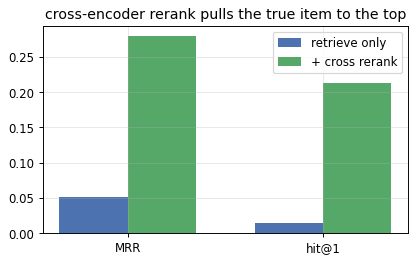

In [95]:
with torch.no_grad():
    ITE = iT(Ite); QTE = qT(Qte)                    # STAGE-0: precompute ALL item vectors (indexable)
K = 50
def order_for(i, stage):
    with torch.no_grad():
        dual_scores = (QTE[i:i+1] @ ITE.T).squeeze(0)     # STAGE 1: dual retrieval
        topK = torch.topk(dual_scores, K).indices
        if stage == "dual":
            return topK[torch.argsort(dual_scores[topK], descending=True)].tolist()
        cross_scores = cx(Qte[i:i+1].repeat(K, 1), Ite[topK])   # STAGE 2: cross re-scores those K jointly
        return topK[torch.argsort(cross_scores, descending=True)].tolist()

# one query, illustrative: where does its TRUE item (index i) land before vs after rerank?
i = 7
do, co = order_for(i, "dual"), order_for(i, "cross")
rank = lambda order: (order.index(i) + 1) if i in order else None

print(f"query {i}: true item rank  ->  dual retrieval: {rank(do)}   after cross rerank: {rank(co)}")

def mrr_hit(stage, n=600):
    rr, hit = [], 0
    for i in range(n):
        order = order_for(i, stage)
        if i in order:
            r = order.index(i) + 1; rr.append(1.0/r); hit += (r == 1)
        else: rr.append(0.0)
    return np.mean(rr), hit/n
d_mrr, d_hit = mrr_hit("dual"); c_mrr, c_hit = mrr_hit("cross")

print(f"\nover 600 queries:")
print(f"  retrieve-only : MRR {d_mrr:.3f}   hit@1 {d_hit:.3f}")
print(f"  + cross rerank: MRR {c_mrr:.3f}   hit@1 {c_hit:.3f}   <- true item pulled toward the top")

xb = np.arange(2); w = 0.35
plt.figure(figsize=(5,3.2))
plt.bar(xb-w/2, [d_mrr, d_hit], w, color=BLUE, label="retrieve only")
plt.bar(xb+w/2, [c_mrr, c_hit], w, color=GREEN, label="+ cross rerank")
plt.xticks(xb, ["MRR", "hit@1"]); plt.legend(); plt.title("cross-encoder rerank pulls the true item to the top"); plt.show()

## Step 6 · The contrastive loss — InfoNCE + temperature

Contrastive training makes the positive **win a softmax** against negatives:
$$\mathcal{L}_i=-\log\frac{\exp(s(q_i,d_i^+)/\tau)}{\sum_j \exp(s(q_i,d_j)/\tau)}$$
`τ` (**temperature**) controls sharpness: **low τ magnifies score gaps**, giving high-scoring
(hard) negatives a bigger gradient. Tiny example: scores `[2.0, 1.0, 0.0]` (positive first).

  tau=1.0 : positive prob 0.665,  loss 0.41
  tau=0.5 : positive prob 0.867,  loss 0.14
  tau=0.1 : positive prob 1.000,  loss 0.00

lower tau -> sharper: the positive's probability shoots up once it's ahead,
and a CLOSE hard negative gets a much larger gradient (more pressure).


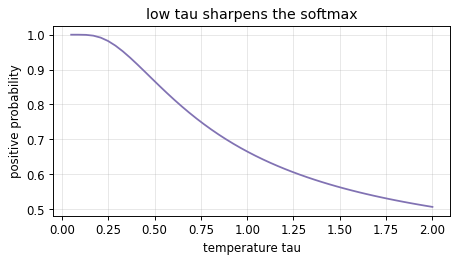

In [97]:
def infonce(scores, tau):
    z = np.array(scores)/tau; z = z - z.max()
    p = np.exp(z)/np.exp(z).sum()
    return p[0], -np.log(p[0])
for tau in [1.0, 0.5, 0.1]:
    p, l = infonce([2.0, 1.0, 0.0], tau)
    print(f"  tau={tau:<4}: positive prob {p:.3f},  loss {l:.2f}")

print("\nlower tau -> sharper: the positive's probability shoots up once it's ahead,")
print("and a CLOSE hard negative gets a much larger gradient (more pressure).")

taus = np.linspace(0.05, 2, 50)
plt.figure(figsize=(5.5,3.2)); plt.plot(taus, [infonce([2.0,1.0,0.0], t)[0] for t in taus], color=PURPLE)
plt.xlabel("temperature tau"); plt.ylabel("positive probability"); plt.title("low tau sharpens the softmax"); plt.show()

## Step 7 · In-batch negatives — the score **matrix**

The cheapest negatives are **free**: in a batch of B (query, positive) pairs, each query's
positive is the diagonal, and **every other pair's positive is a negative** for it. Build the
matrix `S[i,j] = sim(query_i, positive_j)`:

- **diagonal** `S[i,i]` = the correct match (should be **high**)
- **off-diagonal** `S[i,j]`, j≠i = in-batch negatives (should be **low**)

InfoNCE is then just **cross-entropy** on this matrix with labels `[0,1,2,...,B-1]` — "for row
i, pick column i." A batch of 128 gives every query 1 positive + 127 negatives for free, which
is why **bigger batches train better**.

score matrix S (rows=queries, cols=candidate positives):
[[ 0.15 -0.01 -0.54 -0.47 -0.4  -0.67 -0.2  -0.16]
 [ 0.12  0.28 -0.38 -0.27 -0.29 -0.44  0.05 -0.28]
 [ 0.32 -0.2   0.14 -0.22  0.09 -0.14 -0.18  0.06]
 [ 0.03  0.21 -0.38  0.14 -0.32 -0.09  0.13 -0.74]
 [ 0.08 -0.21 -0.04 -0.42  0.19 -0.35 -0.28  0.04]
 [ 0.23 -0.06 -0.08  0.08 -0.21  0.06  0.1  -0.34]
 [-0.08  0.05 -0.55 -0.23 -0.4  -0.43  0.19 -0.34]
 [-0.05 -0.34 -0.09 -0.56 -0.36 -0.1  -0.25  0.11]]

diagonal (correct) mean = 0.158   <- should be HIGH
off-diagonal (in-batch negatives) mean = -0.189   <- should be LOW
InfoNCE label for row i is exactly i (the diagonal).


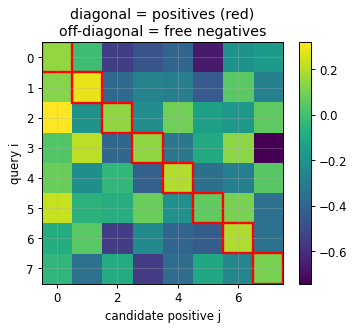

In [99]:
with torch.no_grad():
    B = 8
    qe, ie = qT(Q[:B]), iT(I[:B])
    qe = qe / qe.norm(dim=1, keepdim=True); ie = ie / ie.norm(dim=1, keepdim=True)
    S = (qe @ ie.T).numpy()

print("score matrix S (rows=queries, cols=candidate positives):")
print(np.round(S, 2))
print(f"\ndiagonal (correct) mean = {np.mean(np.diag(S)):.3f}   <- should be HIGH")

off = S[~np.eye(B, dtype=bool)]

print(f"off-diagonal (in-batch negatives) mean = {off.mean():.3f}   <- should be LOW")
print("InfoNCE label for row i is exactly i (the diagonal).")

fig, ax = plt.subplots(figsize=(4.6,4))
im = ax.imshow(S, cmap="viridis")
for i in range(B): ax.add_patch(plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False, edgecolor="red", lw=2))
ax.set_xlabel("candidate positive j"); ax.set_ylabel("query i")
ax.set_title("diagonal = positives (red)\noff-diagonal = free negatives"); fig.colorbar(im, fraction=0.046); plt.show()

### From the matrix to the loss (real numbers)

InfoNCE is **just cross-entropy on that matrix**. Take 3 pairs, divide by `τ`, softmax each
**row**, and the loss is `-log(diagonal probability)`. Here is every number.

In [101]:
Qv = np.array([[0.9,0.1],[0.1,0.9],[0.8,0.6]], dtype=float)    # 3 query vectors
Pv = np.array([[0.8,0.2],[0.2,0.8],[0.7,0.7]], dtype=float)    # 3 item vectors; pair i<->i are matches
Qn = Qv/np.linalg.norm(Qv,axis=1,keepdims=True); Pn = Pv/np.linalg.norm(Pv,axis=1,keepdims=True)
tau = 0.1
S3 = Qn @ Pn.T

print("S = queries . items^T :\n", S3.round(3))
print(f"\nS / tau  (tau={tau}) :\n", (S3/tau).round(2))

Z = S3/tau; Z = Z - Z.max(1, keepdims=True); P3 = np.exp(Z); P3 = P3/P3.sum(1, keepdims=True)

print("\nrow softmax (prob each query puts on each item) :\n", P3.round(3))

losses = [-np.log(P3[i, i]) for i in range(3)]

print(f"\nper-query loss  -log(diagonal prob) = {np.round(losses,3)}")
print(f"InfoNCE batch loss = mean = {np.mean(losses):.3f}   <- backprop minimizes THIS number")
print("row 2 has the highest loss: item0 (~0.31) steals probability from the correct item2 -> a hard negative.")

S = queries . items^T :
 [[0.991 0.348 0.781]
 [0.348 0.991 0.781]
 [0.922 0.776 0.99 ]]

S / tau  (tau=0.1) :
 [[9.91 3.48 7.81]
 [3.48 9.91 7.81]
 [9.22 7.76 9.9 ]]

row softmax (prob each query puts on each item) :
 [[0.89  0.001 0.109]
 [0.001 0.89  0.109]
 [0.311 0.073 0.616]]

per-query loss  -log(diagonal prob) = [0.117 0.117 0.484]
InfoNCE batch loss = mean = 0.239   <- backprop minimizes THIS number
row 2 has the highest loss: item0 (~0.31) steals probability from the correct item2 -> a hard negative.


### Train the dual encoder with in-batch InfoNCE

Now train for real: each batch builds the score matrix, divides by `τ`, and applies
cross-entropy against the diagonal labels. Then measure **recall@k**.

In [103]:
def train_infonce(tau=0.1, epochs=25, use_hard=False):
    torch.manual_seed(0)
    mrng = np.random.default_rng(123)                  # deterministic hard-negative mining
    qt, it = Tower(), Tower(); opt = torch.optim.Adam(list(qt.parameters())+list(it.parameters()), lr=0.01)
    B = 128
    for ep in range(epochs):
        perm = torch.randperm(len(Q))
        for k in range(0, len(Q), B):
            idx = perm[k:k+B]; qe, ie = qt(Q[idx]), it(I[idx])
            S = qe @ ie.T / tau; labels = torch.arange(len(idx))
            if use_hard:                                   # add one mined hard negative per query
                hard = []
                for j in idx.tolist():
                    cand = np.where(tpq == tpq[j])[0]; cand = cand[cand != j]   # same topic, not the positive
                    hard.append(mrng.choice(cand) if len(cand) else j)
                Sh = (qe * it(I[torch.tensor(hard)])).sum(1, keepdim=True) / tau
                S = torch.cat([S, Sh], dim=1)
            opt.zero_grad(); nn.functional.cross_entropy(S, labels).backward(); opt.step()
    with torch.no_grad(): return (qt(Qte) @ it(Ite).T).numpy()

def recall_at_k(S, k): return float(np.mean([r in np.argpartition(-S[r], k)[:k] for r in range(len(S))]))
S_easy = train_infonce()
for k in [1, 5, 10]:
    print(f"recall@{k:>2}: {recall_at_k(S_easy, k):.2f}")

recall@ 1: 0.43
recall@ 5: 0.84
recall@10: 0.95


## Step 8 · The collapse break-case

If the encoder maps **everything to nearly the same vector**, all scores in a row are similar,
the softmax can't put the positive above negatives, and retrieval fails. Contrastive learning
needs **alignment** (positives close) **and** spread (**uniformity**) — the M11 idea. We
simulate a collapsed encoder and watch recall crater.

recall@10  trained encoder : 0.95
recall@10  collapsed space : 0.01   <- can't separate anything


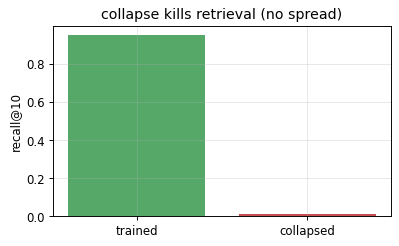

In [105]:
# collapsed: push all vectors to almost one direction
v = rng.normal(0, 1, D_raw)
Qc = torch.tensor((0.02*Qte.numpy() + v), dtype=torch.float32)
Ic = torch.tensor((0.02*Ite.numpy() + v), dtype=torch.float32)
collapsed = (Qc @ Ic.T).numpy()

print(f"recall@10  trained encoder : {recall_at_k(S_easy,10):.2f}")
print(f"recall@10  collapsed space : {recall_at_k(collapsed,10):.2f}   <- can't separate anything")

plt.figure(figsize=(4.8,3)); plt.bar(["trained","collapsed"], [recall_at_k(S_easy,10), recall_at_k(collapsed,10)], color=[GREEN, RED])
plt.ylabel("recall@10"); plt.title("collapse kills retrieval (no spread)"); plt.show()

---
# Part B · Hard negatives & fine-tuning

## Step 9 · Triplet loss — a margin between positive and negative

An alternative to the softmax: a **triplet** (anchor query `q`, positive `p`, negative `n`)
with a **margin** `m`. Loss is zero **only** when the positive beats the negative by at least
`m`:
$$\mathcal{L}=\max(0,\; m + s(q,n) - s(q,p))$$
InfoNCE (Step 5) is the many-negatives generalization of this one-positive-one-negative form.

s(q,p)=3.0, s(q,n)=2.8, margin 0.5 -> 0.3  (still work to do)
s(q,p)=3.0, s(q,n)=0.2, margin 0.5 -> 0.0  (easy neg -> 0 loss, teaches little)


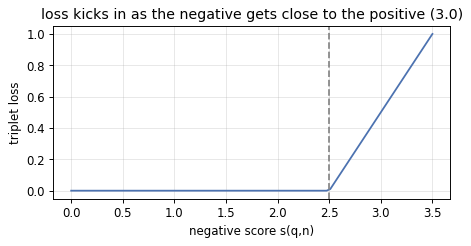

In [108]:
def triplet(s_qp, s_qn, m=0.5): return max(0.0, m + s_qn - s_qp)

print("s(q,p)=3.0, s(q,n)=2.8, margin 0.5 ->", round(triplet(3.0, 2.8), 2), " (still work to do)")
print("s(q,p)=3.0, s(q,n)=0.2, margin 0.5 ->", round(triplet(3.0, 0.2), 2), " (easy neg -> 0 loss, teaches little)")

sn = np.linspace(0, 3.5, 100)
plt.figure(figsize=(5.5,3)); plt.plot(sn, [triplet(3.0, x) for x in sn], color=BLUE)
plt.axvline(2.5, color=GRAY, ls="--"); plt.xlabel("negative score s(q,n)"); plt.ylabel("triplet loss")
plt.title("loss kicks in as the negative gets close to the positive (3.0)"); plt.show()

## Step 10 · Why hard negatives raise the gradient

In the softmax, a negative with a **high score** contributes a large term to the denominator,
**stealing probability** from the positive and keeping the loss (and gradient) high. Easy
negatives contribute almost nothing. Example: positive 3.0, easy 0.2, **hard 2.8**.

positive probability WITH hard negative : 0.53 -> loss 0.63
positive probability WITHOUT it          : 0.94 -> loss 0.06
that gap (0.53 vs 0.94) is the training signal a hard negative provides.


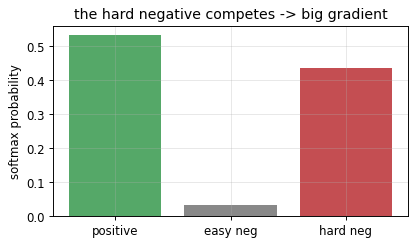

In [110]:
def softmax(x): x = x - x.max(); return np.exp(x)/np.exp(x).sum()
with_hard    = softmax(np.array([3.0, 0.2, 2.8]))
without_hard = softmax(np.array([3.0, 0.2]))

print("positive probability WITH hard negative :", round(with_hard[0], 2), "-> loss", round(-np.log(with_hard[0]),2))
print("positive probability WITHOUT it          :", round(without_hard[0], 2), "-> loss", round(-np.log(without_hard[0]),2))

plt.figure(figsize=(5,3)); plt.bar(["positive","easy neg","hard neg"], with_hard, color=[GREEN, GRAY, RED])
plt.ylabel("softmax probability"); plt.title("the hard negative competes -> big gradient"); plt.show()

print("that gap (0.53 vs 0.94) is the training signal a hard negative provides.")

## Step 11 · How you actually **mine** hard negatives (the pipeline)

You don't guess hard negatives — you let the **current model** surface them, then **filter**.
The real loop:

```
1. Train a first-pass encoder (in-batch negatives only).
2. ENCODE the whole corpus  -> vectors -> ANN index (M13).
3. For each query, RETRIEVE top-k with the current model.
4. PICK the high-ranked items that are NOT the labeled positive  = hard negatives
   (they look right to the model but are wrong).
5. FILTER likely FALSE negatives: drop candidates scoring within a margin of the
   positive (those may be true matches that just aren't labeled).
6. RETRAIN with these hard negatives added; optionally re-mine (ANCE-style).
```

We run one query through steps 2–5 on a small corpus and watch which candidates are **kept** vs
**filtered**.

labeled positive id=0  score=0.997  (rank 2)
top-8 retrieved:
   id   2  score 0.998  topic 0  same-topic
   id   1  score 0.998  topic 0  same-topic
   id   0  score 0.997  topic 0  <-POSITIVE
   id 299  score 0.984  topic 0  same-topic
   id 183  score 0.983  topic 0  same-topic
   id  78  score 0.978  topic 0  same-topic
   id 201  score 0.971  topic 0  same-topic
   id  13  score 0.961  topic 0  same-topic

filter: drop candidates scoring within 0.03 of the positive (0.997):
   DROPPED (too similar -> maybe true match): [2, 1, 299, 183, 78, 201]
   KEPT hard negatives:                       [13, 211, 104, 43, 271, 77, 156, 133]
   => kept 18 usable hard negatives, filtered 6 risky ones.


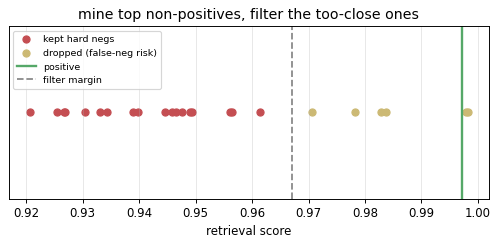

In [112]:
# small corpus with topics; the labeled positive sits in the query's topic
mr = np.random.default_rng(1); d = 8; Tt = 6; Nc = 300
ctr = mr.normal(0,1,(Tt,d))*2.0
it_t = mr.integers(0,Tt,Nc); corp = ctr[it_t] + mr.normal(0,0.6,(Nc,d))
qtopic = 0
qv = ctr[qtopic] + mr.normal(0,0.2,d)
corp[0] = qv + mr.normal(0,0.15,d); it_t[0] = qtopic          # true positive: close to query
corp[1] = qv + mr.normal(0,0.12,d); it_t[1] = qtopic          # near-duplicate (likely FALSE neg)
corp[2] = qv + mr.normal(0,0.13,d); it_t[2] = qtopic          # near-duplicate (likely FALSE neg)
corp = corp/np.linalg.norm(corp,axis=1,keepdims=True); qv = qv/np.linalg.norm(qv)
pos_id = 0

scores = corp @ qv                                            # step 3: retrieve by current model
ranked = np.argsort(-scores)

print(f"labeled positive id={pos_id}  score={scores[pos_id]:.3f}  (rank {list(ranked).index(pos_id)})")
print("top-8 retrieved:")

for r in ranked[:8]:
    tag = "<-POSITIVE" if r==pos_id else ("same-topic" if it_t[r]==qtopic else "diff-topic")
    print(f"   id {r:3d}  score {scores[r]:.3f}  topic {it_t[r]}  {tag}")

hard = [r for r in ranked[:25] if r != pos_id]                # step 4: high-ranked non-positives
margin = 0.03                                                 # step 5: filter likely false negatives
kept    = [r for r in hard if scores[r] <  scores[pos_id]-margin]
dropped = [r for r in hard if scores[r] >= scores[pos_id]-margin]

print(f"\nfilter: drop candidates scoring within {margin} of the positive ({scores[pos_id]:.3f}):")
print(f"   DROPPED (too similar -> maybe true match): {dropped[:8]}")
print(f"   KEPT hard negatives:                       {kept[:8]}")
print(f"   => kept {len(kept)} usable hard negatives, filtered {len(dropped)} risky ones.")

plt.figure(figsize=(6,3))
plt.scatter([scores[r] for r in kept],   [1]*len(kept),   color=RED,  label="kept hard negs")
plt.scatter([scores[r] for r in dropped],[1]*len(dropped),color=GOLD, label="dropped (false-neg risk)")
plt.axvline(scores[pos_id], color=GREEN, lw=2, label="positive")
plt.axvline(scores[pos_id]-margin, color=GRAY, ls="--", label="filter margin")
plt.yticks([]); plt.xlabel("retrieval score"); plt.legend(fontsize=8); plt.title("mine top non-positives, filter the too-close ones"); plt.show()

## Step 12 · Mining hard negatives improves fine-grained recall

Random/in-batch negatives are usually **easy** (different topic) — they teach broad separation
but leave the model fuzzy **within** a topic. Adding **mined hard negatives** (same-topic, not
the positive) forces the model to separate look-alikes, so **fine-grained recall (recall@1)
rises.**

                  recall@1  recall@5  recall@10
  easy negs only      0.43      0.84       0.95
     + hard negs      0.55      0.92       0.98
biggest gain is at recall@1 (the hardest, most fine-grained rank).


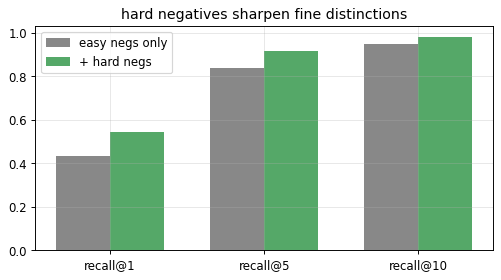

In [114]:
S_easy = train_infonce(use_hard=False)
S_hard = train_infonce(use_hard=True)

print(f"{'':>16}{'recall@1':>10}{'recall@5':>10}{'recall@10':>11}")
print(f"{'easy negs only':>16}{recall_at_k(S_easy,1):>10.2f}{recall_at_k(S_easy,5):>10.2f}{recall_at_k(S_easy,10):>11.2f}")
print(f"{'+ hard negs':>16}{recall_at_k(S_hard,1):>10.2f}{recall_at_k(S_hard,5):>10.2f}{recall_at_k(S_hard,10):>11.2f}")

ks = [1,5,10]
xb = np.arange(len(ks)); w = 0.35
plt.figure(figsize=(6,3.4))
plt.bar(xb-w/2, [recall_at_k(S_easy,k) for k in ks], w, color=GRAY, label="easy negs only")
plt.bar(xb+w/2, [recall_at_k(S_hard,k) for k in ks], w, color=GREEN, label="+ hard negs")
plt.xticks(xb, [f"recall@{k}" for k in ks]); plt.legend(); plt.title("hard negatives sharpen fine distinctions"); plt.show()

print("biggest gain is at recall@1 (the hardest, most fine-grained rank).")

## Step 13 · The catch — false negatives

A mined "hard negative" must **actually be negative**. Two valid items for one query look like a
hard pair; treating one as a negative teaches the model to **separate valid matches** — damaging
the encoder. So mine hard negatives, then **filter** likely false negatives (labels, business
rules, a cross-encoder), and validate false-negative-heavy slices.

In [116]:
miners = pd.DataFrame({
    "miner": ["BM25 (lexical)", "current model", "other retrieval model", "cross-encoder", "human/model filter"],
    "finds": ["same words, wrong meaning", "close in vector space, wrong attribute",
              "audience overlap, wrong content", "text matches but a rule forbids it", "removes accepted alternates"],
})

print(miners.to_string(index=False))
print("\ngood batch = easy negs (stability) + filtered hard negs (discrimination).")
print("bad batch  = treat every unclicked plausible item as negative -> false negatives.")

                miner                                  finds
       BM25 (lexical)              same words, wrong meaning
        current model close in vector space, wrong attribute
other retrieval model        audience overlap, wrong content
        cross-encoder     text matches but a rule forbids it
   human/model filter            removes accepted alternates

good batch = easy negs (stability) + filtered hard negs (discrimination).
bad batch  = treat every unclicked plausible item as negative -> false negatives.


## Step 14 · End-to-end encoder fine-tuning recipe

Putting it together — how you actually **fine-tune a text encoder** with a contrastive
objective + hard negatives. The mindset: you **start from a pretrained encoder** that already
"knows language" and **reshape its vector space** so *your* notion of relevant lines up. You do
**not** train from scratch.

```
1. START from a pretrained encoder (E5 / IRPS / BERT).       # don't start from zero
2. Add POOL + NORMALIZE on top -> the sentence vector (Step 2).
3. For each batch of (query, positive) pairs [+ mined hard negs]:
     - encode both sides
     - build the in-batch score matrix / tau          (Step 6)
     - InfoNCE cross-entropy, labels = diagonal
     - backprop, update the encoder weights
4. Use a BIG batch (more in-batch negatives = better); grad-cache if memory-bound.
5. EVAL on retrieval metrics (recall@k / nDCG) on held-out data, not just loss.
6. (Optional) do a MINING round (Step 10) and continue training.
```

Below is that loop in miniature: we "warm-start" from the Step-6 encoder, then continue training
**with mined hard negatives** and confirm held-out recall@1 improves — i.e. fine-tuning moved
the geometry in the right direction.

fine-tuning progress (held-out recall@1):
  after warm start (easy negs)    : recall@1 = 0.397
  after round 1 (+ hard negs)     : recall@1 = 0.514
  after round 2 (+ hard negs)     : recall@1 = 0.526


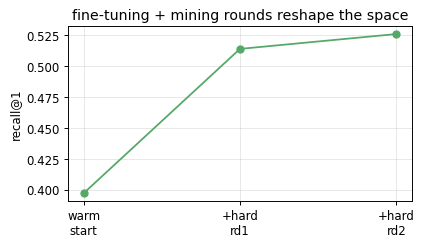

In [118]:
# a compact fine-tuning loop: warm-start a fresh encoder, then adapt with hard negatives.
def finetune(rounds=2, epochs=8, tau=0.1, mine=True):
    torch.manual_seed(1); mrng = np.random.default_rng(7)
    qt, it = Tower(), Tower()
    opt = torch.optim.Adam(list(qt.parameters())+list(it.parameters()), lr=0.01)
    hist = []
    for rd in range(rounds):
        for ep in range(epochs):
            perm = torch.randperm(len(Q)); Bt = 128
            for k in range(0, len(Q), Bt):
                idx = perm[k:k+Bt]; qe, ie = qt(Q[idx]), it(I[idx])
                S = qe @ ie.T / tau; labels = torch.arange(len(idx))
                if mine and rd > 0:                            # round 0 = warm start; then mine
                    hard = []
                    for j in idx.tolist():
                        cand = np.where(tpq == tpq[j])[0]; cand = cand[cand != j]
                        hard.append(mrng.choice(cand) if len(cand) else j)
                    Sh = (qe * it(I[torch.tensor(hard)])).sum(1, keepdim=True) / tau
                    S = torch.cat([S, Sh], dim=1)
                opt.zero_grad(); nn.functional.cross_entropy(S, labels).backward(); opt.step()
        with torch.no_grad(): Ste = (qt(Qte) @ it(Ite).T).numpy()
        r1 = recall_at_k(Ste, 1); hist.append(r1)
        stage = "warm start (easy negs)" if rd == 0 else f"round {rd} (+ hard negs)"
        print(f"  after {stage:26}: recall@1 = {r1:.3f}")
    return hist

print("fine-tuning progress (held-out recall@1):")

hist = finetune(rounds=3, epochs=8)
plt.figure(figsize=(5,3)); plt.plot(range(len(hist)), hist, "o-", color=GREEN)
plt.xticks(range(len(hist)), ["warm\nstart","+hard\nrd1","+hard\nrd2"]); plt.ylabel("recall@1")
plt.title("fine-tuning + mining rounds reshape the space"); plt.show()

## Step 15 · Evaluating on held-out data — recall@k and nDCG

You never judge an encoder on the queries it trained on (it could just memorize). You keep a
**held-out set**: labeled queries **set aside and never trained on**, used only to measure. E.g.
10,000 labeled queries → **train on 9,000, hold out 1,000**; report metrics on the 1,000.

Two metrics, worked on one query with graded relevance (`2`=great, `1`=ok, `0`=irrelevant):
- **recall@k** — of all relevant items, how many landed in the top-k? ("did we *find* them?")
- **nDCG@k** — reward relevant items ranked **early**, via a `1/log2(rank+1)` discount, then
  normalize by the best-possible ordering. ("did we *order* them well?")

model ranking : ['d1', 'd2', 'd3', 'd4', 'd5']
true relevance: [0, 2, 0, 1, 0]  (2=great, 1=ok, 0=irrelevant)

  recall@1 = 0/2 = 0.00
  recall@3 = 1/2 = 0.50
  recall@5 = 2/2 = 1.00

  DCG@5  = 2/log2(3) + 1/log2(5) = 1.693
  IDCG@5 = ideal [2,1,0,0,0]      = 2.631
  nDCG@5 = DCG/IDCG = 0.643   (1.0 = perfect ordering)

You compute both PER held-out query, then AVERAGE across the whole held-out set.


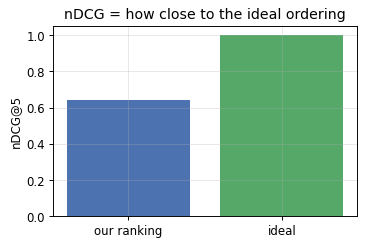

In [120]:
# one held-out query: the model's ranking + the TRUE relevance of each returned item
ranked = ["d1", "d2", "d3", "d4", "d5"]
rel    = {"d1": 0, "d2": 2, "d3": 0, "d4": 1, "d5": 0}     # ground-truth labels (held-out)
rels   = [rel[x] for x in ranked]

print("model ranking :", ranked)
print("true relevance:", rels, " (2=great, 1=ok, 0=irrelevant)\n")

# recall@k : relevant = rel>0 ; here d2,d4 are relevant -> 2 total
total_rel = sum(1 for v in rel.values() if v > 0)
for k in [1, 3, 5]:
    found = sum(1 for x in ranked[:k] if rel[x] > 0)
    print(f"  recall@{k} = {found}/{total_rel} = {found/total_rel:.2f}")

# nDCG@k : DCG = sum rel/log2(rank+1) ; IDCG = DCG of the ideal order ; nDCG = DCG/IDCG
def dcg(vals, k): return sum(r/np.log2(i+2) for i, r in enumerate(vals[:k]))
k = 5
DCG  = dcg(rels, k)
IDCG = dcg(sorted(rel.values(), reverse=True), k)          # ideal order [2,1,0,0,0]

print(f"\n  DCG@{k}  = 2/log2(3) + 1/log2(5) = {DCG:.3f}")
print(f"  IDCG@{k} = ideal [2,1,0,0,0]      = {IDCG:.3f}")
print(f"  nDCG@{k} = DCG/IDCG = {DCG/IDCG:.3f}   (1.0 = perfect ordering)")
print("\nYou compute both PER held-out query, then AVERAGE across the whole held-out set.")

# bar chart: our ranking's nDCG vs the ideal
plt.figure(figsize=(4.4,3)); plt.bar(["our ranking","ideal"], [DCG/IDCG, 1.0], color=[BLUE, GREEN])
plt.ylim(0,1.05); plt.ylabel(f"nDCG@{k}"); plt.title("nDCG = how close to the ideal ordering"); plt.show()

---
## Recap — the M14 toolkit

**Encoders (Part A).** A **sentence encoder** is *text → tokens → transformer → **pool** →
**normalize*** → one vector (what M11 stores, M13 indexes); **E5** adds `query:/passage:`
prefixes, **IRPS** is LinkedIn's in-house version. A **dual encoder = two-tower = bi-encoder**:
query and item embedded **separately** (score = dot), so item vectors **precompute & index** for
retrieval. A **cross-encoder** reads the pair **jointly** — more accurate but **O(pairs)**, so
it's used to **rerank** the top-K from the dual encoder (**retrieve → rerank**). **InfoNCE**
makes the positive win a softmax; **temperature τ** controls sharpness; **in-batch negatives**
are the off-diagonal of the query×item **score matrix** (labels = the diagonal). A **collapsed**
space can't separate anything — you need **alignment + uniformity** (M11).

**Hard negatives & fine-tuning (Part B).** **Triplet loss** enforces a margin between one
positive and one negative; InfoNCE generalizes it to many. A **hard negative** competes in the
softmax → **raises the gradient** and teaches fine distinctions. You **mine** them with a real
pipeline — **encode → retrieve → pick top non-positives → filter false negatives** — then
**retrain** (optionally re-mine, ANCE-style). **Fine-tuning** = start from a **pretrained**
encoder, add pool+normalize, train InfoNCE with big batches + mined hard negatives, and **eval
on recall@k** — reshaping the geometry so retrieval lands the right items.

**Where this connects:** M14 is *how* the encoders behind M11 embeddings and M12/M13 retrieval
are trained; its retrieve→rerank and hard-negative discipline are what make the candidate sets
good enough for the downstream ranker.